In [1]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.draw import disk, line

import seaborn as sns




-----

# Model task without ITI

([], [])

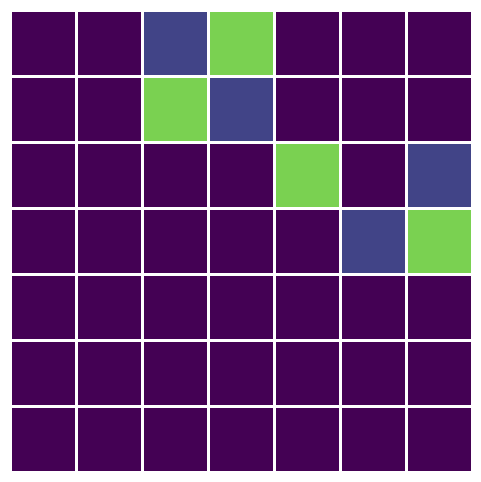

In [2]:
states_iti = ['right','left','up','down','up_reward','down_reward','no_reward',]
# node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5)}
                        #0              1              2              3              4                    5.                  6
node_coordinates_iti = {'right': (1,1), 'left': (1,3), 'up': (2,3), 'down': (2,1), 'up_reward': (3,3), 'down_reward': (3,1), 'no_reward': (3,2),}



# define SR
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 0.8
graph_iti[0,2] = 0.2
graph_iti[1,3] = 0.2
graph_iti[1,2] = 0.8
graph_iti[2,4] = 0.8
graph_iti[3,5] = 0.2
graph_iti[2,6] = 0.2
graph_iti[3,6] = 0.8 # down leads to no-reward mostly in this example bias block


# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="viridis", linecolor='white', linewidths=1, square=True, vmin=0, vmax=1, cbar=False)
# fit range of color bar
# remove ticks
plt.xticks([])
plt.yticks([])

# save svg, make transparent
# plt.savefig("Figures_grids/Fig6_mouse2steptask_graph_no_iti.svg", format="svg", transparent=True)

([], [])

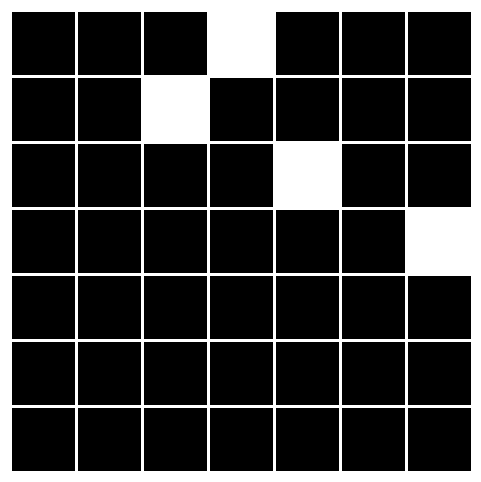

In [3]:
# define Graph
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 1
# graph_iti[0,2] = 0.2
# graph_iti[1,3] = 0.2
graph_iti[1,2] = 1
graph_iti[2,4] = 1
graph_iti[3,6] = 1
# graph_iti[4,6] = 0.2
# graph_iti[3,6] = 0.2



# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="grey", linecolor='white', linewidths=1, cbar=False, square=True)
# remove ticks
plt.xticks([])
plt.yticks([])



# Left eigenvectors (Goal-state activty)

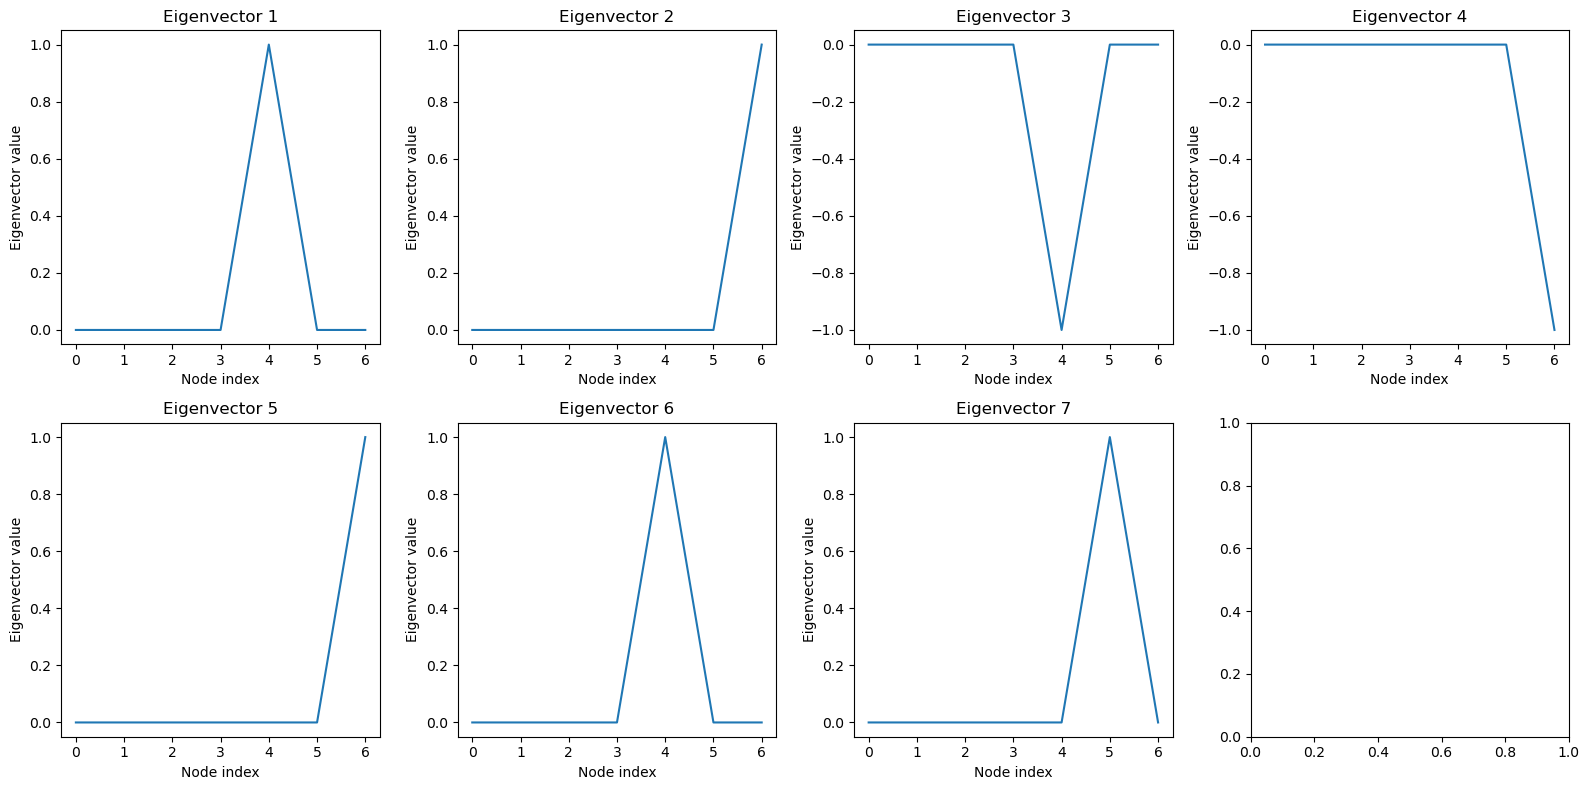

In [4]:
eigvals_iti, eigvecs_iti = np.linalg.eig(np.transpose(graph_iti))

# ones = np.ones(len(states_no_iti))

# we want to plot a heatmap of the eigenvector on the graph
# we have the intensities of the heatmap at each node coordinate
# create a meshgrid with gaussian interpolation

# plot the eigenvectors on 7 separate plots
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()
for i in range(len(eigvecs_iti)):
    ax = axs[i]
    ax.plot(eigvecs_iti[:,i])
    ax.set_title(f'Eigenvector {i+1}')
    ax.set_xlabel('Node index')
    ax.set_ylabel('Eigenvector value')
plt.tight_layout()
plt.show()


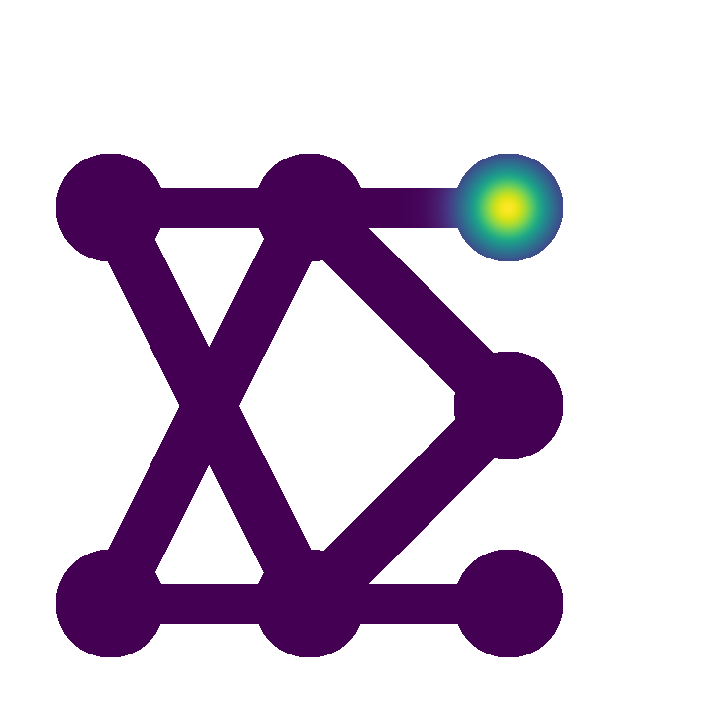

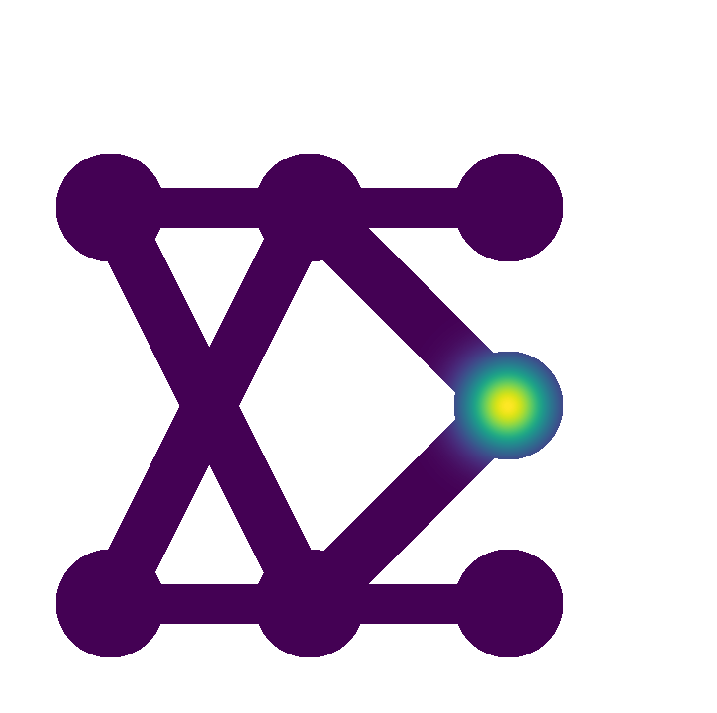

In [5]:
# Show first 2 eigenvectors
# for n in range(len(eigvecs_iti)):
for n in range(2):

    eigvec = eigvecs_iti[:,n]
    # take the real part
    eigvec = np.real(eigvec)
    # scale between -1 and 1
    eigvec = (eigvec - np.min(eigvec)) / (np.max(eigvec) - np.min(eigvec))

    ones = np.ones(len(eigvecs_iti))

    res = 1000

    x = np.linspace(0, 5, res)
    y = np.linspace(0, 5, res)
    X, Y = np.meshgrid(x, y)
    aspect_ratio = (X[0,1] - X[0,0]) / (Y[1,0] - Y[0,0])
    Z = np.zeros((res,res))
    # for each node coordinate, get the value of the eigenvector
    for i in range(len(states_iti)):
        x_coord = node_coordinates_iti[states_iti[i]][0]
        y_coord = node_coordinates_iti[states_iti[i]][1]
        Z += eigvec[i] * np.exp(-((X - x_coord)**2 + (Y - y_coord)**2)/0.05)
    # # create a figure
    # fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))
    # #ax.set_aspect('equal')

    # ax.imshow(Z, cmap='viridis', interpolation='nearest')
    # # remove ticks



    # #ax.colorbar()
    # ax.set_title('Heatmap of Eigenvector %d on the Graph' % n)


    # Heatmap size
    H = len(Z)
    W = len(Z[0]) # Assuming all rows have the same number of columns

    data = np.random.rand(H, W)

    # Define nodes as (row, col) coordinates
    nodes = list(node_coordinates_iti.values())#[(4812, 924), (3000, 3000), (6500, 3000),(3000, 5000), (6500, 5000)]
    nodes = [(r*200, c*200) for (r, c) in nodes]
    nodes = [(c, r) for (r, c) in nodes]
    # edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5),(5,7),(6,7),(4,7)]
    edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5)]




    # node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5), 'iti': (3,0.5),'iti': (4,0.5)}


    # Create mask: True = hide, False = show
    mask = np.ones((H, W), dtype=bool)

    # Draw circular nodes
    for (r, c) in nodes:
        rr, cc = disk((r, c), radius=55, shape=mask.shape)
        mask[rr, cc] = False  # Keep circle

    # Draw edges between nodes
    for i, j in edges:
        r1, c1 = nodes[i]
        r2, c2 = nodes[j]
        rr, cc = line(r1, c1, r2, c2)
        mask[rr, cc] = False  # Keep edge
        # Optionally thicken the line
        for dr in range(-20, 20):
            for dc in range(-20, 20):
                rr2 = np.clip(rr + dr, 0, H - 1)
                cc2 = np.clip(cc + dc, 0, W - 1)
                mask[rr2, cc2] = False


    fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))

    ax = sns.heatmap(Z,mask=mask,  cmap='viridis', cbar=False)




    # remove x and y ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # invert y axis
    ax.invert_yaxis()
    # set limits xaxis
    ax.set_xlim(100, 800)

    ax.set_ylim(100, 800)


    # font arial
    plt.rc('font', family='Arial')
    # ax.set_title('Heatmap of Eigenvector / No ITI -  %d on the Graph' % n)

        # save figure as svg
    # plt.savefig(f'Figures_grids/Fig6_mouse2step_noITI_heatmap_eigenvector_{n}.pdf', format='pdf', dpi=50, bbox_inches='tight')

# Right eigenvectors (Entry-state activity)

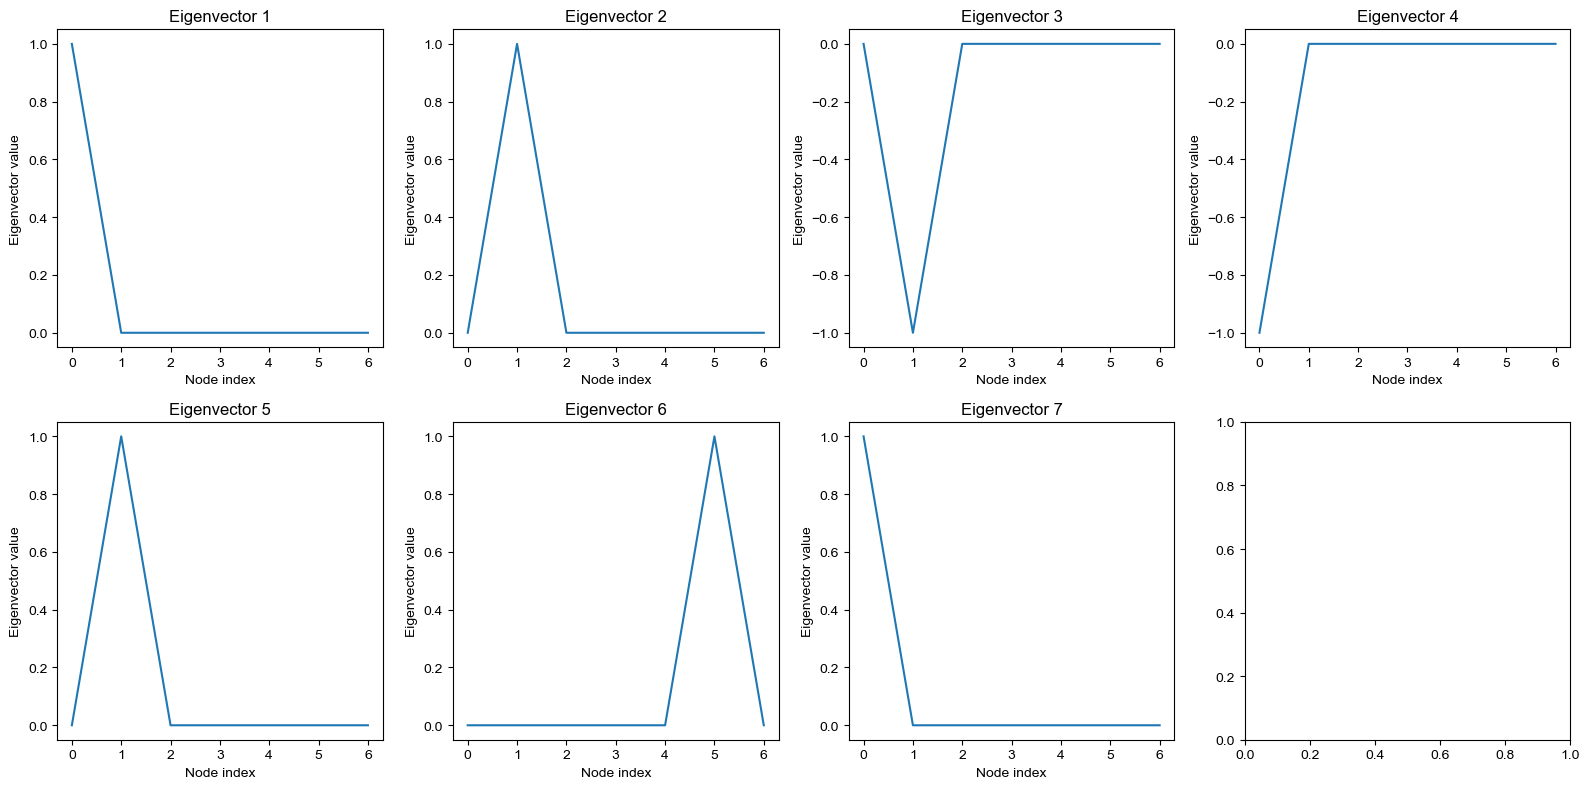

In [6]:


eigvals_iti, eigvecs_iti = np.linalg.eig(graph_iti)


# ones = np.ones(len(states_no_iti))

# we want to plot a heatmap of the eigenvector on the graph
# we have the intensities of the heatmap at each node coordinate
# create a meshgrid with gaussian interpolation

# plot the eigenvectors on 7 separate plots
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()
for i in range(len(eigvecs_iti)):
    ax = axs[i]
    ax.plot(eigvecs_iti[:,i])
    ax.set_title(f'Eigenvector {i+1}')
    ax.set_xlabel('Node index')
    ax.set_ylabel('Eigenvector value')
plt.tight_layout()
plt.show()


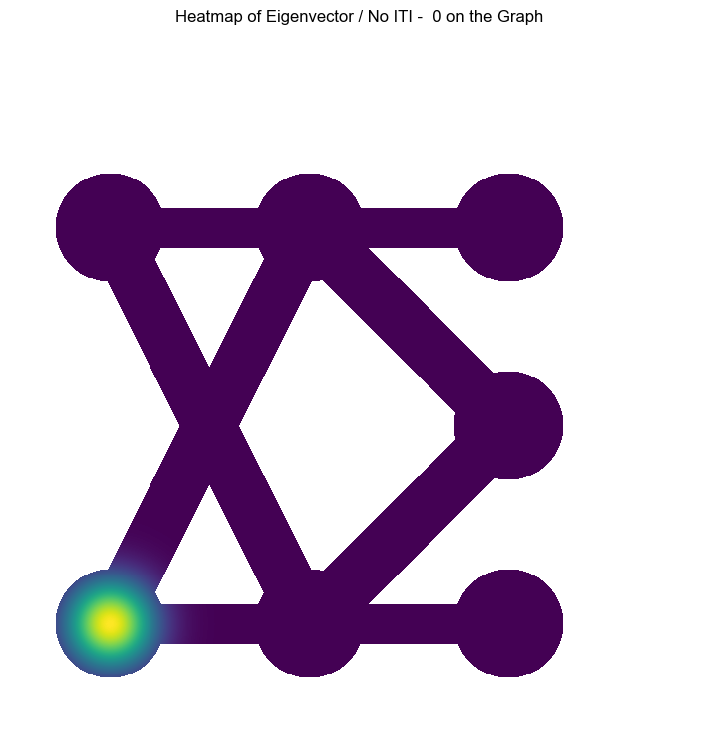

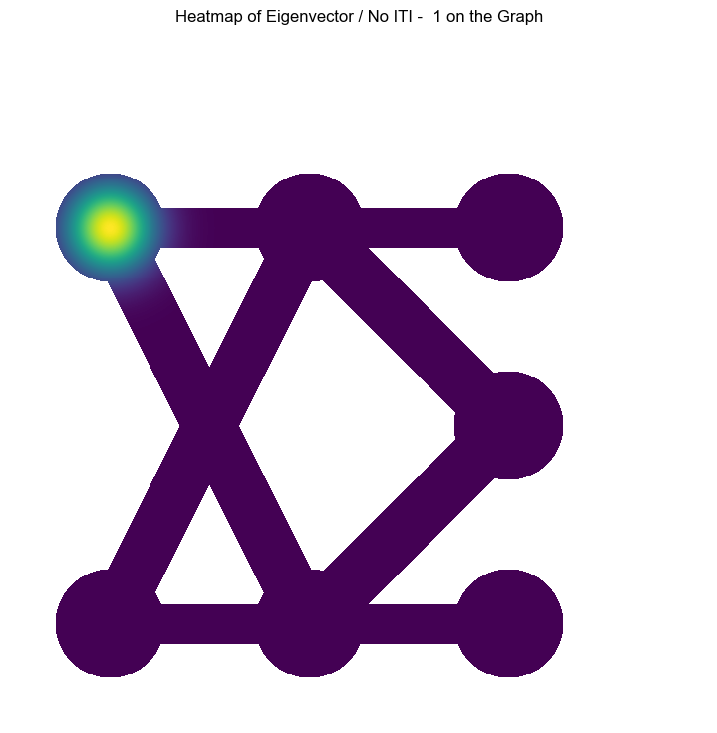

In [7]:
#pick an eigenvector

# for n in range(len(eigvecs_iti)):
for n in range(2):

    eigvec = eigvecs_iti[:,n]
    # take the real part
    eigvec = np.real(eigvec)
    # scale between -1 and 1
    eigvec = (eigvec - np.min(eigvec)) / (np.max(eigvec) - np.min(eigvec))

    ones = np.ones(len(eigvecs_iti))

    res = 1000

    x = np.linspace(0, 5, res)
    y = np.linspace(0, 5, res)
    X, Y = np.meshgrid(x, y)
    aspect_ratio = (X[0,1] - X[0,0]) / (Y[1,0] - Y[0,0])
    Z = np.zeros((res,res))
    # for each node coordinate, get the value of the eigenvector
    for i in range(len(states_iti)):
        x_coord = node_coordinates_iti[states_iti[i]][0]
        y_coord = node_coordinates_iti[states_iti[i]][1]
        Z += eigvec[i] * np.exp(-((X - x_coord)**2 + (Y - y_coord)**2)/0.05)
    # # create a figure
    # fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))
    # #ax.set_aspect('equal')

    # ax.imshow(Z, cmap='viridis', interpolation='nearest')
    # # remove ticks



    # #ax.colorbar()
    # ax.set_title('Heatmap of Eigenvector %d on the Graph' % n)


    # Heatmap size
    H = len(Z)
    W = len(Z[0]) # Assuming all rows have the same number of columns

    data = np.random.rand(H, W)

    # Define nodes as (row, col) coordinates
    nodes = list(node_coordinates_iti.values())#[(4812, 924), (3000, 3000), (6500, 3000),(3000, 5000), (6500, 5000)]
    nodes = [(r*200, c*200) for (r, c) in nodes]
    nodes = [(c, r) for (r, c) in nodes]
    # edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5),(5,7),(6,7),(4,7)]
    edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5)]




    # node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5), 'iti': (3,0.5),'iti': (4,0.5)}


    # Create mask: True = hide, False = show
    mask = np.ones((H, W), dtype=bool)

    # Draw circular nodes
    for (r, c) in nodes:
        rr, cc = disk((r, c), radius=55, shape=mask.shape)
        mask[rr, cc] = False  # Keep circle

    # Draw edges between nodes
    for i, j in edges:
        r1, c1 = nodes[i]
        r2, c2 = nodes[j]
        rr, cc = line(r1, c1, r2, c2)
        mask[rr, cc] = False  # Keep edge
        # Optionally thicken the line
        for dr in range(-20, 20):
            for dc in range(-20, 20):
                rr2 = np.clip(rr + dr, 0, H - 1)
                cc2 = np.clip(cc + dc, 0, W - 1)
                mask[rr2, cc2] = False


    fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))

    ax = sns.heatmap(Z,mask=mask,  cmap='viridis', cbar=False)




    # remove x and y ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # invert y axis
    ax.invert_yaxis()
    # set limits xaxis
    ax.set_xlim(100, 800)

    ax.set_ylim(100, 800)


    # font arial
    plt.rc('font', family='Arial')
    ax.set_title('Heatmap of Eigenvector / No ITI -  %d on the Graph' % n)

        # save figure as svg
    # plt.savefig(f'Figures_grids/Fig6_mouse2step_noITI_heatmap_eigenvector_{n}.pdf', format='pdf', dpi=50, bbox_inches='tight')

----

----

# Predictions without ITI --- Pre Stimulation

([], [])

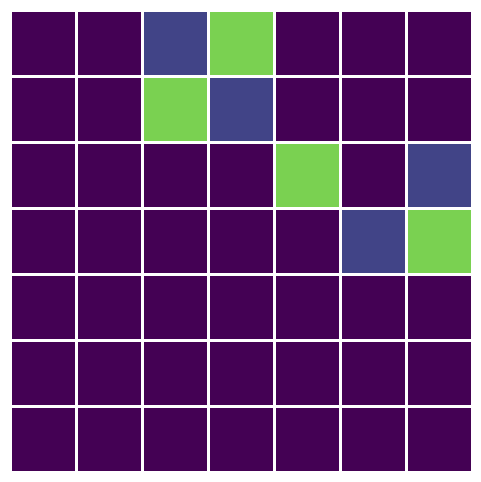

In [8]:
states_iti = ['right','left','up','down','up_reward','down_reward','no_reward',]
# node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5)}
                        #0              1              2              3              4                    5.                  6
node_coordinates_iti = {'right': (1,1), 'left': (1,3), 'up': (2,3), 'down': (2,1), 'up_reward': (3,3), 'down_reward': (3,1), 'no_reward': (3,2),}



# define SR
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 0.8
graph_iti[0,2] = 0.2
graph_iti[1,3] = 0.2
graph_iti[1,2] = 0.8
graph_iti[2,4] = 0.8
graph_iti[3,5] = 0.2
graph_iti[2,6] = 0.2
graph_iti[3,6] = 0.8 # down leads to no-reward mostly in this example bias block


# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="viridis", linecolor='white', linewidths=1, square=True, vmin=0, vmax=1, cbar=False)
# fit range of color bar
# remove ticks
plt.xticks([])
plt.yticks([])

# save svg, make transparent
# plt.savefig("Figures_grids/Fig6_mouse2steptask_graph_no_iti.svg", format="svg", transparent=True)

([], [])

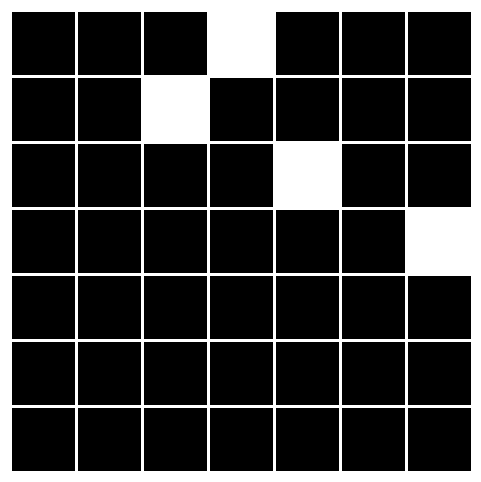

In [9]:
# define Graph
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 1
# graph_iti[0,2] = 0.2
# graph_iti[1,3] = 0.2
graph_iti[1,2] = 1
graph_iti[2,4] = 1
graph_iti[3,6] = 1
# graph_iti[4,6] = 0.2
# graph_iti[3,6] = 0.2



# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="grey", linecolor='white', linewidths=1, cbar=False, square=True)
# remove ticks
plt.xticks([])
plt.yticks([])



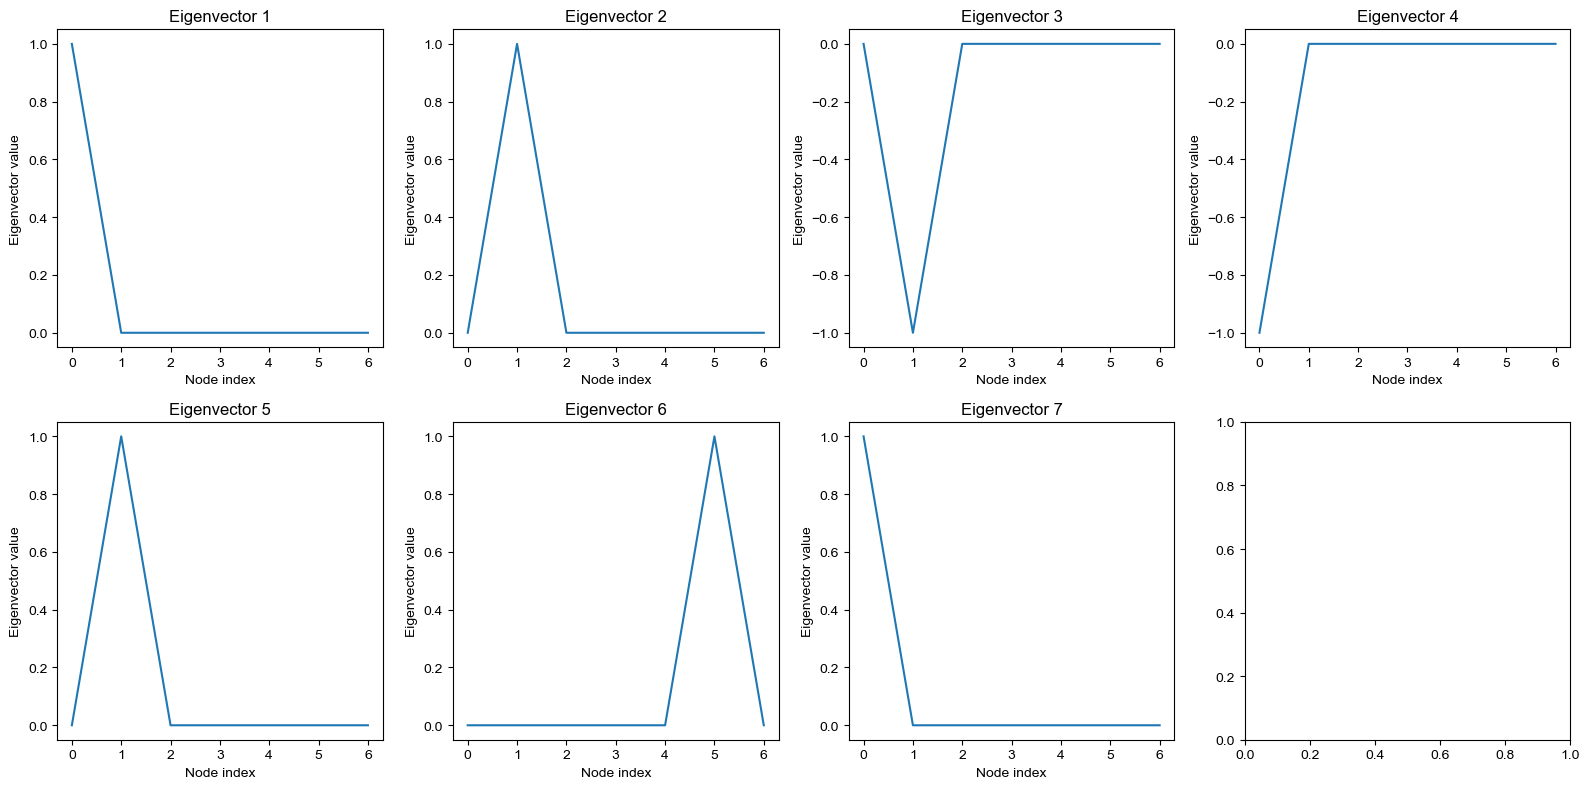

In [10]:


eigvals_iti, eigvecs_iti = np.linalg.eig(graph_iti)


# ones = np.ones(len(states_no_iti))

# we want to plot a heatmap of the eigenvector on the graph
# we have the intensities of the heatmap at each node coordinate
# create a meshgrid with gaussian interpolation

# plot the eigenvectors on 7 separate plots
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()
for i in range(len(eigvecs_iti)):
    ax = axs[i]
    ax.plot(eigvecs_iti[:,i])
    ax.set_title(f'Eigenvector {i+1}')
    ax.set_xlabel('Node index')
    ax.set_ylabel('Eigenvector value')
plt.tight_layout()
plt.show()


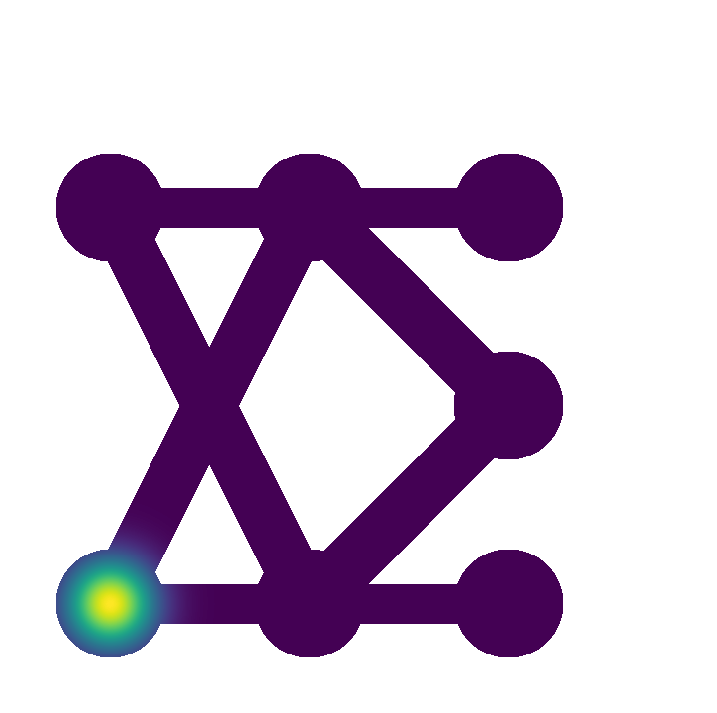

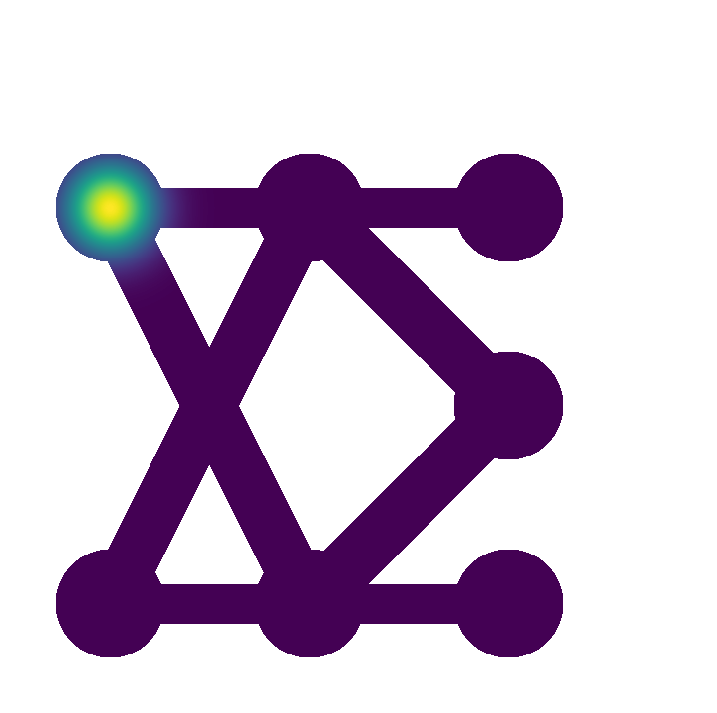

In [11]:
#pick an eigenvector


# for n in range(len(eigvecs_iti)):
for n in range(2):

    eigvec = eigvecs_iti[:,n]
    # take the real part
    eigvec = np.real(eigvec)
    # scale between -1 and 1
    eigvec = (eigvec - np.min(eigvec)) / (np.max(eigvec) - np.min(eigvec))

    ones = np.ones(len(eigvecs_iti))

    res = 1000

    x = np.linspace(0, 5, res)
    y = np.linspace(0, 5, res)
    X, Y = np.meshgrid(x, y)
    aspect_ratio = (X[0,1] - X[0,0]) / (Y[1,0] - Y[0,0])
    Z = np.zeros((res,res))
    # for each node coordinate, get the value of the eigenvector
    for i in range(len(states_iti)):
        x_coord = node_coordinates_iti[states_iti[i]][0]
        y_coord = node_coordinates_iti[states_iti[i]][1]
        Z += eigvec[i] * np.exp(-((X - x_coord)**2 + (Y - y_coord)**2)/0.05)
    # # create a figure
    # fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))
    # #ax.set_aspect('equal')

    # ax.imshow(Z, cmap='viridis', interpolation='nearest')
    # # remove ticks



    # #ax.colorbar()
    # ax.set_title('Heatmap of Eigenvector %d on the Graph' % n)


    # Heatmap size
    H = len(Z)
    W = len(Z[0]) # Assuming all rows have the same number of columns

    data = np.random.rand(H, W)

    # Define nodes as (row, col) coordinates
    nodes = list(node_coordinates_iti.values())#[(4812, 924), (3000, 3000), (6500, 3000),(3000, 5000), (6500, 5000)]
    nodes = [(r*200, c*200) for (r, c) in nodes]
    nodes = [(c, r) for (r, c) in nodes]
    # edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5),(5,7),(6,7),(4,7)]
    edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5)]




    # node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5), 'iti': (3,0.5),'iti': (4,0.5)}


    # Create mask: True = hide, False = show
    mask = np.ones((H, W), dtype=bool)

    # Draw circular nodes
    for (r, c) in nodes:
        rr, cc = disk((r, c), radius=55, shape=mask.shape)
        mask[rr, cc] = False  # Keep circle

    # Draw edges between nodes
    for i, j in edges:
        r1, c1 = nodes[i]
        r2, c2 = nodes[j]
        rr, cc = line(r1, c1, r2, c2)
        mask[rr, cc] = False  # Keep edge
        # Optionally thicken the line
        for dr in range(-20, 20):
            for dc in range(-20, 20):
                rr2 = np.clip(rr + dr, 0, H - 1)
                cc2 = np.clip(cc + dc, 0, W - 1)
                mask[rr2, cc2] = False


    fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))

    ax = sns.heatmap(Z,mask=mask,  cmap='viridis', cbar=False)




    # remove x and y ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # invert y axis
    ax.invert_yaxis()
    # set limits xaxis
    ax.set_xlim(100, 800)

    ax.set_ylim(100, 800)


    # font arial
    plt.rc('font', family='Arial')
    # ax.set_title('Heatmap of Eigenvector / No ITI -  %d on the Graph' % n)

        # save figure as svg
    # plt.savefig(f'Figures_grids/Fig6_mouse2step_noITI_heatmap_eigenvector_{n}.pdf', format='pdf', dpi=50, bbox_inches='tight')

# Predictions without ITI --- Post Stimulation

([], [])

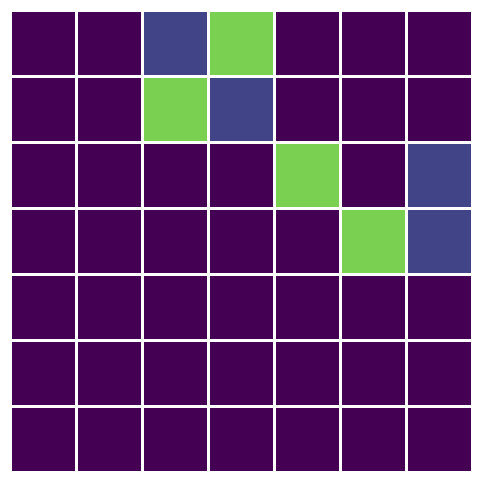

In [12]:
states_iti = ['right','left','up','down','up_reward','down_reward','no_reward',]
# node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5)}
                        #0              1              2              3              4                    5.                  6
node_coordinates_iti = {'right': (1,1), 'left': (1,3), 'up': (2,3), 'down': (2,1), 'up_reward': (3,3), 'down_reward': (3,1), 'no_reward': (3,2),}

# define SR
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 0.8
graph_iti[0,2] = 0.2
graph_iti[1,3] = 0.2
graph_iti[1,2] = 0.8
graph_iti[2,4] = 0.8
graph_iti[3,5] = 0.8
graph_iti[2,6] = 0.2
graph_iti[3,6] = 0.2 # down leads to no-reward mostly in this example bias block

# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="viridis", linecolor='white', linewidths=1, square=True, vmin=0, vmax=1, cbar=False)
# fit range of color bar
# remove ticks
plt.xticks([])
plt.yticks([])

# save svg, make transparent
# plt.savefig("Figures_grids/Fig6_mouse2steptask_graph_no_iti.svg", format="svg", transparent=True)

([], [])

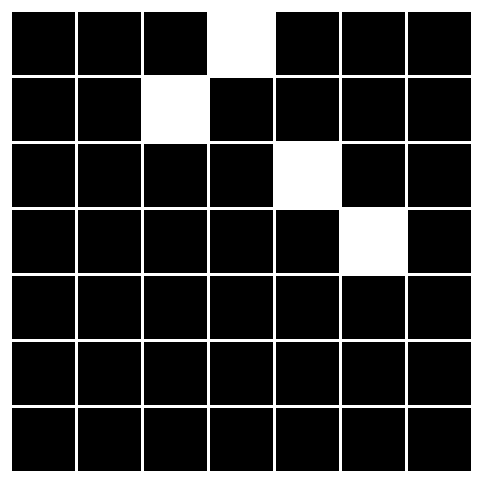

In [13]:
# define Graph
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 1
# graph_iti[0,2] = 0.2
# graph_iti[1,3] = 0.2
graph_iti[1,2] = 1
graph_iti[2,4] = 1
graph_iti[3,5] = 1
# graph_iti[4,6] = 0.2
# graph_iti[3,6] = 0.2



# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="grey", linecolor='white', linewidths=1, cbar=False, square=True)
# remove ticks
plt.xticks([])
plt.yticks([])



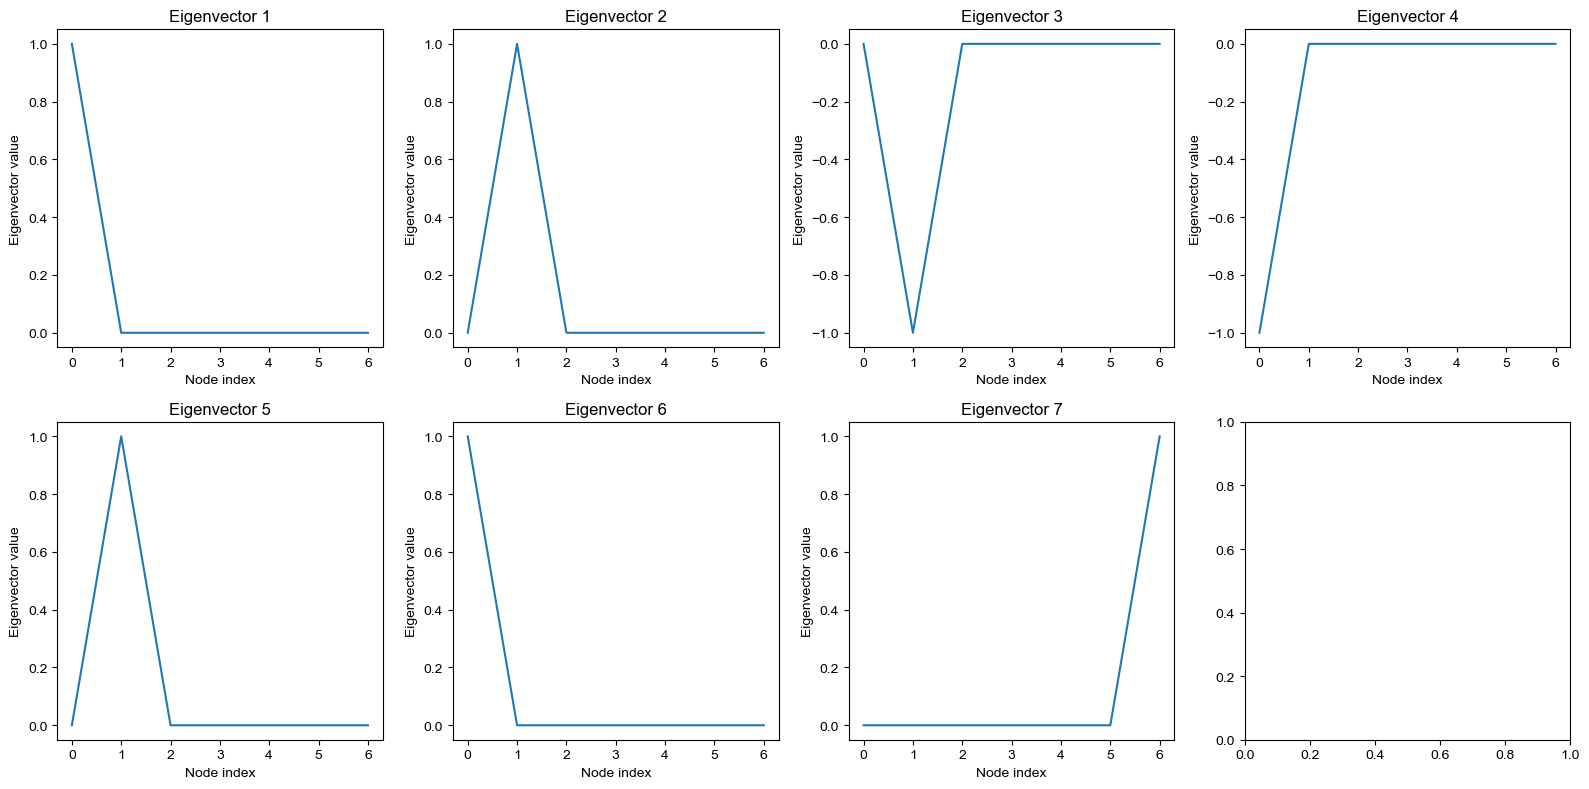

In [14]:


eigvals_iti, eigvecs_iti = np.linalg.eig(graph_iti)


# ones = np.ones(len(states_no_iti))

# we want to plot a heatmap of the eigenvector on the graph
# we have the intensities of the heatmap at each node coordinate
# create a meshgrid with gaussian interpolation

# plot the eigenvectors on 7 separate plots
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()
for i in range(len(eigvecs_iti)):
    ax = axs[i]
    ax.plot(eigvecs_iti[:,i])
    ax.set_title(f'Eigenvector {i+1}')
    ax.set_xlabel('Node index')
    ax.set_ylabel('Eigenvector value')
plt.tight_layout()
plt.show()


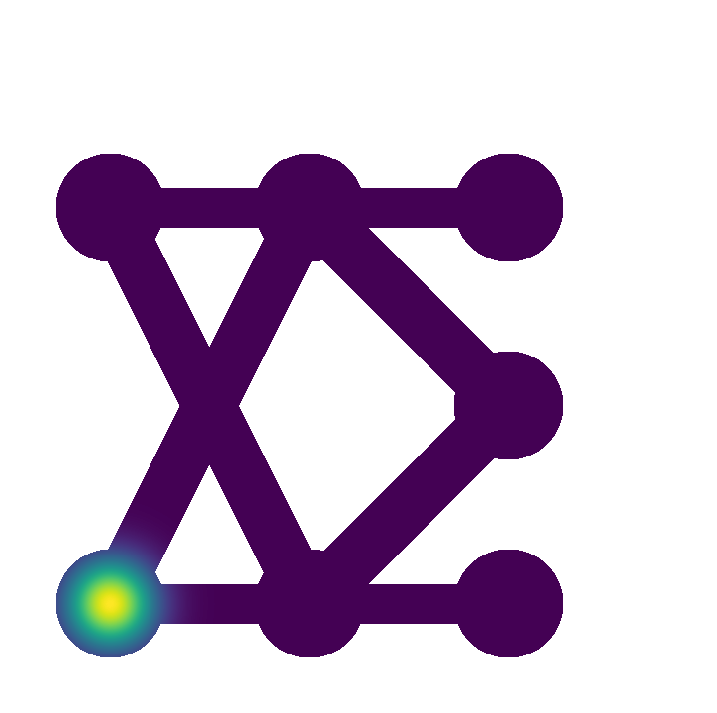

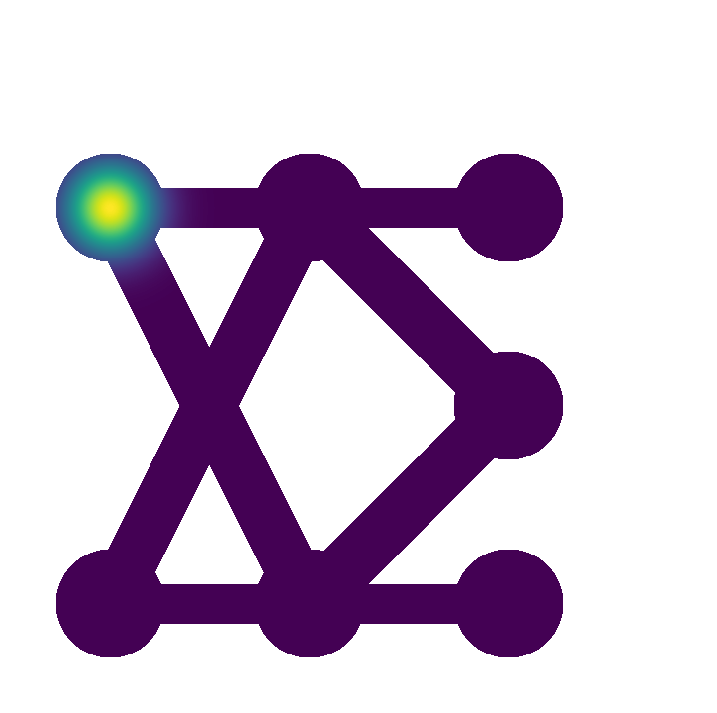

In [15]:
#pick an eigenvector


# for n in range(len(eigvecs_iti)):
for n in range(2):

    eigvec = eigvecs_iti[:,n]
    # take the real part
    eigvec = np.real(eigvec)
    # scale between -1 and 1
    eigvec = (eigvec - np.min(eigvec)) / (np.max(eigvec) - np.min(eigvec))

    ones = np.ones(len(eigvecs_iti))

    res = 1000

    x = np.linspace(0, 5, res)
    y = np.linspace(0, 5, res)
    X, Y = np.meshgrid(x, y)
    aspect_ratio = (X[0,1] - X[0,0]) / (Y[1,0] - Y[0,0])
    Z = np.zeros((res,res))
    # for each node coordinate, get the value of the eigenvector
    for i in range(len(states_iti)):
        x_coord = node_coordinates_iti[states_iti[i]][0]
        y_coord = node_coordinates_iti[states_iti[i]][1]
        Z += eigvec[i] * np.exp(-((X - x_coord)**2 + (Y - y_coord)**2)/0.05)
    # # create a figure
    # fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))
    # #ax.set_aspect('equal')

    # ax.imshow(Z, cmap='viridis', interpolation='nearest')
    # # remove ticks



    # #ax.colorbar()
    # ax.set_title('Heatmap of Eigenvector %d on the Graph' % n)


    # Heatmap size
    H = len(Z)
    W = len(Z[0]) # Assuming all rows have the same number of columns

    data = np.random.rand(H, W)

    # Define nodes as (row, col) coordinates
    nodes = list(node_coordinates_iti.values())#[(4812, 924), (3000, 3000), (6500, 3000),(3000, 5000), (6500, 5000)]
    nodes = [(r*200, c*200) for (r, c) in nodes]
    nodes = [(c, r) for (r, c) in nodes]
    # edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5),(5,7),(6,7),(4,7)]
    edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5)]




    # node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5), 'iti': (3,0.5),'iti': (4,0.5)}


    # Create mask: True = hide, False = show
    mask = np.ones((H, W), dtype=bool)

    # Draw circular nodes
    for (r, c) in nodes:
        rr, cc = disk((r, c), radius=55, shape=mask.shape)
        mask[rr, cc] = False  # Keep circle

    # Draw edges between nodes
    for i, j in edges:
        r1, c1 = nodes[i]
        r2, c2 = nodes[j]
        rr, cc = line(r1, c1, r2, c2)
        mask[rr, cc] = False  # Keep edge
        # Optionally thicken the line
        for dr in range(-20, 20):
            for dc in range(-20, 20):
                rr2 = np.clip(rr + dr, 0, H - 1)
                cc2 = np.clip(cc + dc, 0, W - 1)
                mask[rr2, cc2] = False


    fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))

    ax = sns.heatmap(Z,mask=mask,  cmap='viridis', cbar=False)




    # remove x and y ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # invert y axis
    ax.invert_yaxis()
    # set limits xaxis
    ax.set_xlim(100, 800)

    ax.set_ylim(100, 800)


    # font arial
    plt.rc('font', family='Arial')
    # ax.set_title('Heatmap of Eigenvector / No ITI -  %d on the Graph' % n)

        # save figure as svg
    # plt.savefig(f'Figures_grids/Fig6_mouse2step_noITI_heatmap_eigenvector_{n}.pdf', format='pdf', dpi=50, bbox_inches='tight')

--------

--------

# Predictions  (left eigenvector calculation)

# Predictions without ITI --- Pre Stimulation

([], [])

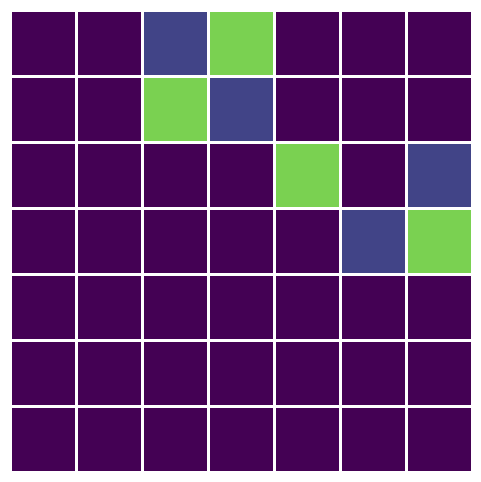

In [16]:
states_iti = ['right','left','up','down','up_reward','down_reward','no_reward',]
# node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5)}
                        #0              1              2              3              4                    5.                  6
node_coordinates_iti = {'right': (1,1), 'left': (1,3), 'up': (2,3), 'down': (2,1), 'up_reward': (3,3), 'down_reward': (3,1), 'no_reward': (3,2),}



# define SR
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 0.8
graph_iti[0,2] = 0.2
graph_iti[1,3] = 0.2
graph_iti[1,2] = 0.8
graph_iti[2,4] = 0.8
graph_iti[3,5] = 0.2
graph_iti[2,6] = 0.2
graph_iti[3,6] = 0.8 # down leads to no-reward mostly in this example bias block


# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="viridis", linecolor='white', linewidths=1, square=True, vmin=0, vmax=1, cbar=False)
# fit range of color bar
# remove ticks
plt.xticks([])
plt.yticks([])

# save svg, make transparent
# plt.savefig("Figures_grids/Fig6_mouse2steptask_graph_no_iti.svg", format="svg", transparent=True)

([], [])

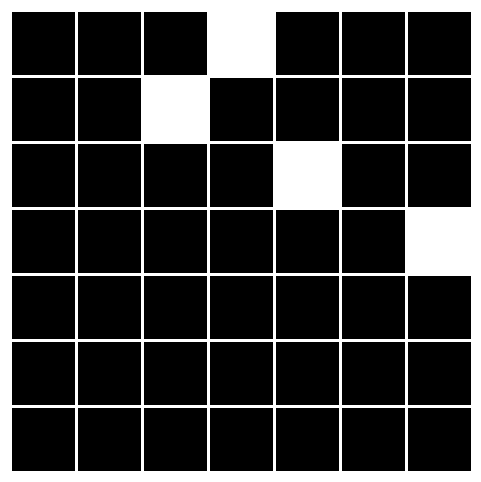

In [17]:
# define Graph
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 1
# graph_iti[0,2] = 0.2
# graph_iti[1,3] = 0.2
graph_iti[1,2] = 1
graph_iti[2,4] = 1
graph_iti[3,6] = 1
# graph_iti[4,6] = 0.2
# graph_iti[3,6] = 0.2



# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="grey", linecolor='white', linewidths=1, cbar=False, square=True)
# remove ticks
plt.xticks([])
plt.yticks([])



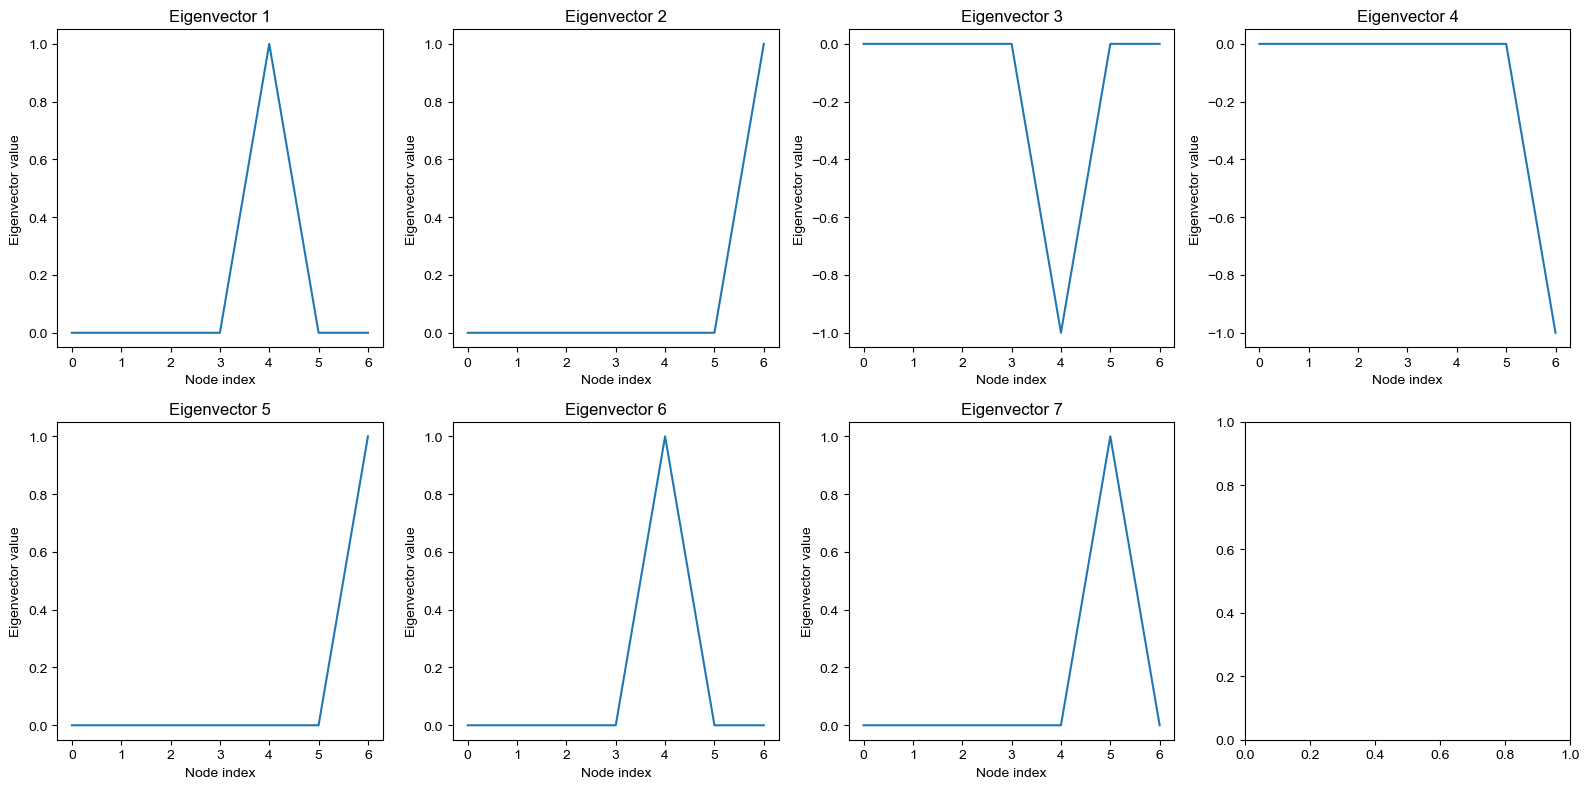

In [18]:


eigvals_iti, eigvecs_iti = np.linalg.eig(np.transpose(graph_iti))


# ones = np.ones(len(states_no_iti))

# we want to plot a heatmap of the eigenvector on the graph
# we have the intensities of the heatmap at each node coordinate
# create a meshgrid with gaussian interpolation

# plot the eigenvectors on 7 separate plots
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()
for i in range(len(eigvecs_iti)):
    ax = axs[i]
    ax.plot(eigvecs_iti[:,i])
    ax.set_title(f'Eigenvector {i+1}')
    ax.set_xlabel('Node index')
    ax.set_ylabel('Eigenvector value')
plt.tight_layout()
plt.show()


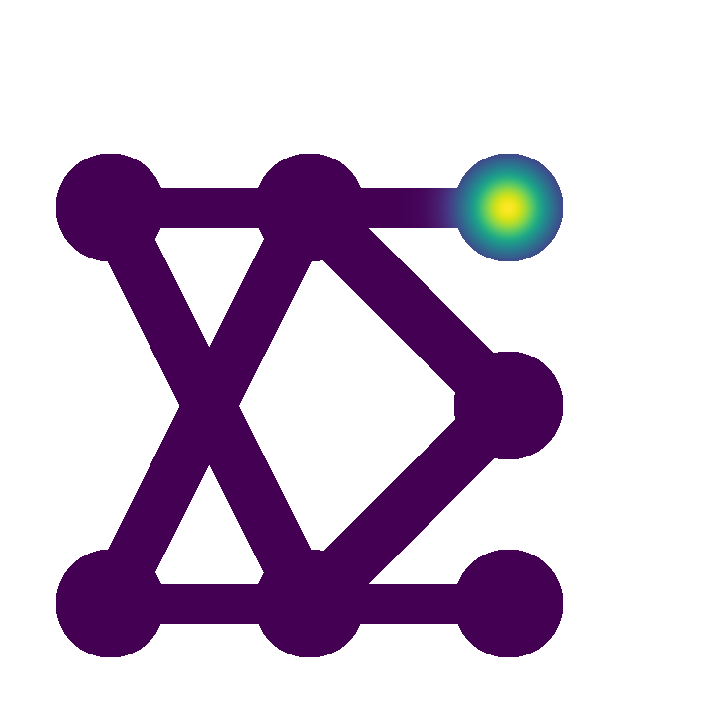

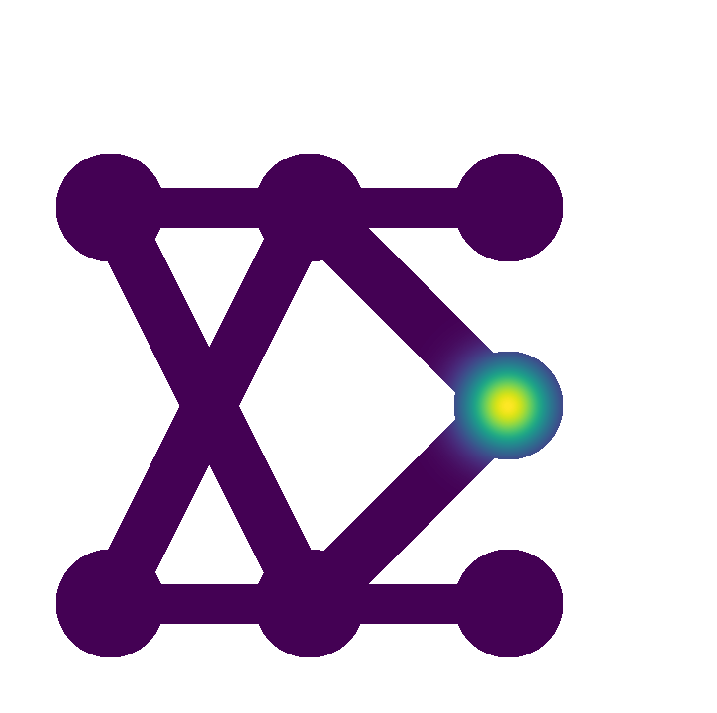

In [19]:
#pick an eigenvector


# for n in range(len(eigvecs_iti)):
for n in range(2):

    eigvec = eigvecs_iti[:,n]
    # take the real part
    eigvec = np.real(eigvec)
    # scale between -1 and 1
    eigvec = (eigvec - np.min(eigvec)) / (np.max(eigvec) - np.min(eigvec))

    ones = np.ones(len(eigvecs_iti))

    res = 1000

    x = np.linspace(0, 5, res)
    y = np.linspace(0, 5, res)
    X, Y = np.meshgrid(x, y)
    aspect_ratio = (X[0,1] - X[0,0]) / (Y[1,0] - Y[0,0])
    Z = np.zeros((res,res))
    # for each node coordinate, get the value of the eigenvector
    for i in range(len(states_iti)):
        x_coord = node_coordinates_iti[states_iti[i]][0]
        y_coord = node_coordinates_iti[states_iti[i]][1]
        Z += eigvec[i] * np.exp(-((X - x_coord)**2 + (Y - y_coord)**2)/0.05)
    # # create a figure
    # fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))
    # #ax.set_aspect('equal')

    # ax.imshow(Z, cmap='viridis', interpolation='nearest')
    # # remove ticks



    # #ax.colorbar()
    # ax.set_title('Heatmap of Eigenvector %d on the Graph' % n)


    # Heatmap size
    H = len(Z)
    W = len(Z[0]) # Assuming all rows have the same number of columns

    data = np.random.rand(H, W)

    # Define nodes as (row, col) coordinates
    nodes = list(node_coordinates_iti.values())#[(4812, 924), (3000, 3000), (6500, 3000),(3000, 5000), (6500, 5000)]
    nodes = [(r*200, c*200) for (r, c) in nodes]
    nodes = [(c, r) for (r, c) in nodes]
    # edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5),(5,7),(6,7),(4,7)]
    edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5)]




    # node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5), 'iti': (3,0.5),'iti': (4,0.5)}


    # Create mask: True = hide, False = show
    mask = np.ones((H, W), dtype=bool)

    # Draw circular nodes
    for (r, c) in nodes:
        rr, cc = disk((r, c), radius=55, shape=mask.shape)
        mask[rr, cc] = False  # Keep circle

    # Draw edges between nodes
    for i, j in edges:
        r1, c1 = nodes[i]
        r2, c2 = nodes[j]
        rr, cc = line(r1, c1, r2, c2)
        mask[rr, cc] = False  # Keep edge
        # Optionally thicken the line
        for dr in range(-20, 20):
            for dc in range(-20, 20):
                rr2 = np.clip(rr + dr, 0, H - 1)
                cc2 = np.clip(cc + dc, 0, W - 1)
                mask[rr2, cc2] = False


    fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))

    ax = sns.heatmap(Z,mask=mask,  cmap='viridis', cbar=False)




    # remove x and y ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # invert y axis
    ax.invert_yaxis()
    # set limits xaxis
    ax.set_xlim(100, 800)

    ax.set_ylim(100, 800)


    # font arial
    plt.rc('font', family='Arial')
    # ax.set_title('Heatmap of Eigenvector / No ITI -  %d on the Graph' % n)

        # save figure as svg
    # plt.savefig(f'Figures_grids/Fig6_mouse2step_noITI_heatmap_eigenvector_{n}.pdf', format='pdf', dpi=50, bbox_inches='tight')

# Predictions without ITI --- Post Stimulation

([], [])

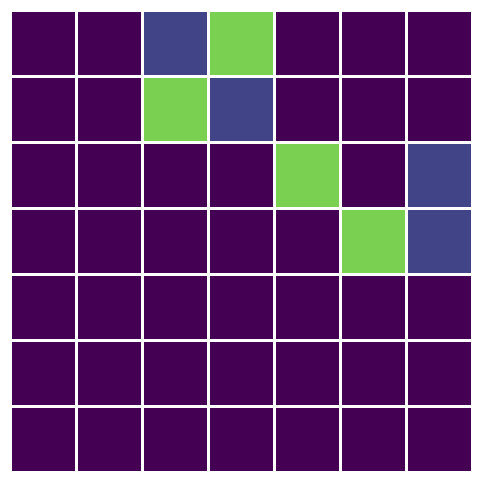

In [20]:
states_iti = ['right','left','up','down','up_reward','down_reward','no_reward',]
# node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5)}
                        #0              1              2              3              4                    5.                  6
node_coordinates_iti = {'right': (1,1), 'left': (1,3), 'up': (2,3), 'down': (2,1), 'up_reward': (3,3), 'down_reward': (3,1), 'no_reward': (3,2),}

# define SR
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 0.8
graph_iti[0,2] = 0.2
graph_iti[1,3] = 0.2
graph_iti[1,2] = 0.8
graph_iti[2,4] = 0.8
graph_iti[3,5] = 0.8
graph_iti[2,6] = 0.2
graph_iti[3,6] = 0.2 # down leads to no-reward mostly in this example bias block


# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="viridis", linecolor='white', linewidths=1, square=True, vmin=0, vmax=1, cbar=False)
# fit range of color bar
# remove ticks
plt.xticks([])
plt.yticks([])

# save svg, make transparent
# plt.savefig("Figures_grids/Fig6_mouse2steptask_graph_no_iti.svg", format="svg", transparent=True)

([], [])

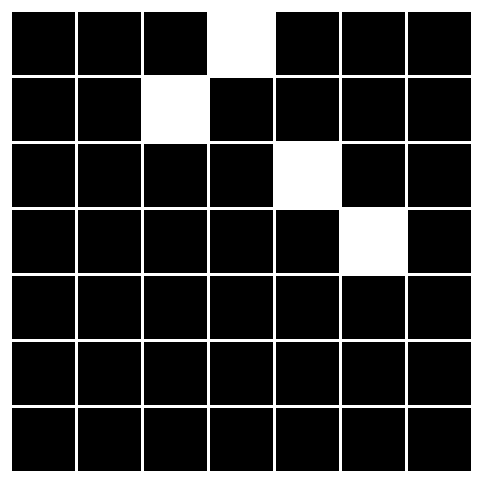

In [21]:
# define Graph
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 1
# graph_iti[0,2] = 0.2
# graph_iti[1,3] = 0.2
graph_iti[1,2] = 1
graph_iti[2,4] = 1
graph_iti[3,5] = 1
# graph_iti[4,6] = 0.2
# graph_iti[3,6] = 0.2



# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="grey", linecolor='white', linewidths=1, cbar=False, square=True)
# remove ticks
plt.xticks([])
plt.yticks([])



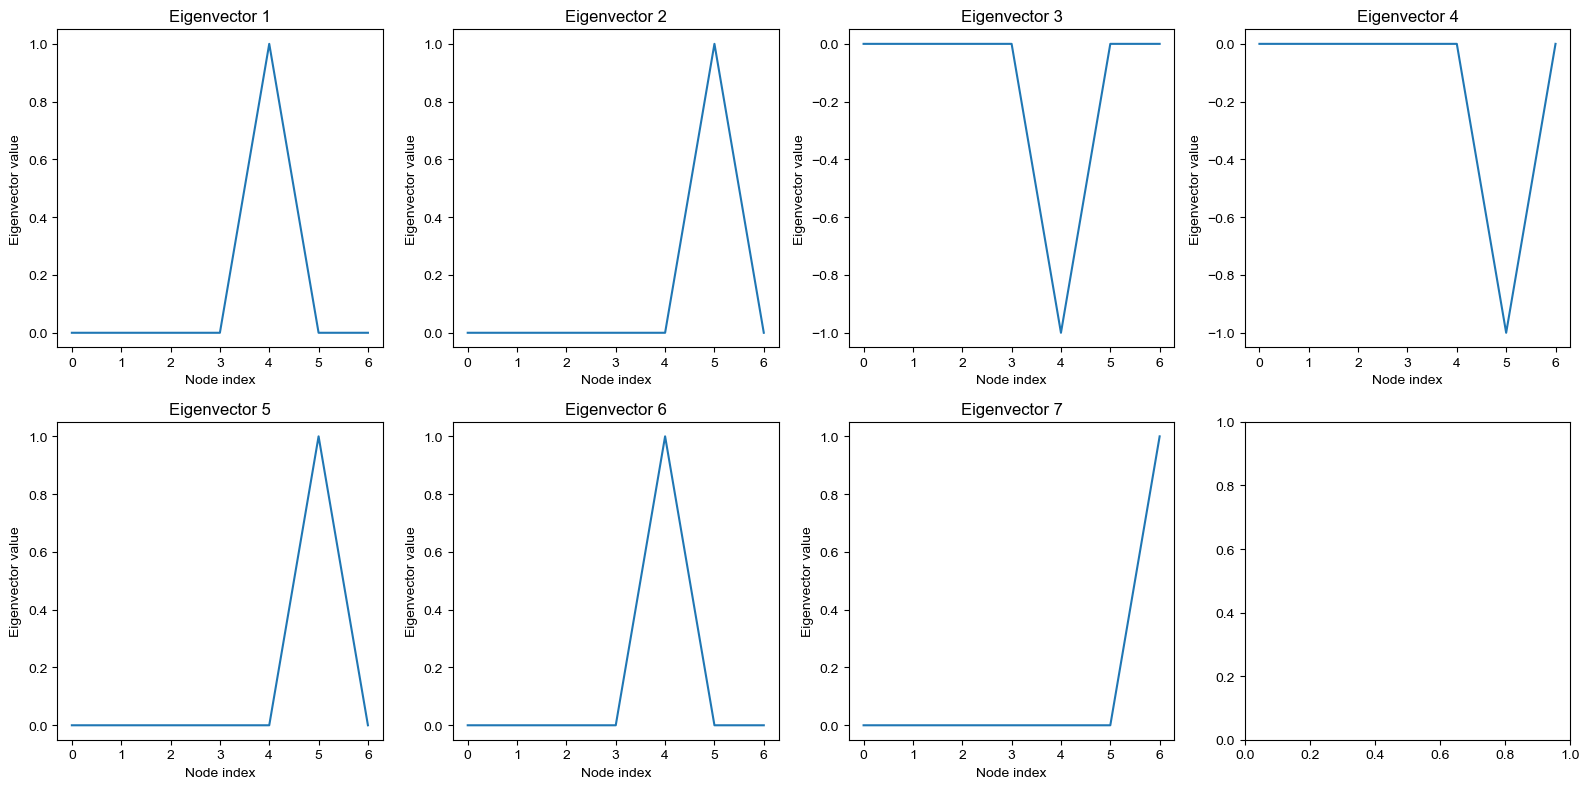

In [22]:


eigvals_iti, eigvecs_iti = np.linalg.eig(np.transpose(graph_iti))


# ones = np.ones(len(states_no_iti))

# we want to plot a heatmap of the eigenvector on the graph
# we have the intensities of the heatmap at each node coordinate
# create a meshgrid with gaussian interpolation

# plot the eigenvectors on 7 separate plots
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()
for i in range(len(eigvecs_iti)):
    ax = axs[i]
    ax.plot(eigvecs_iti[:,i])
    ax.set_title(f'Eigenvector {i+1}')
    ax.set_xlabel('Node index')
    ax.set_ylabel('Eigenvector value')
plt.tight_layout()
plt.show()


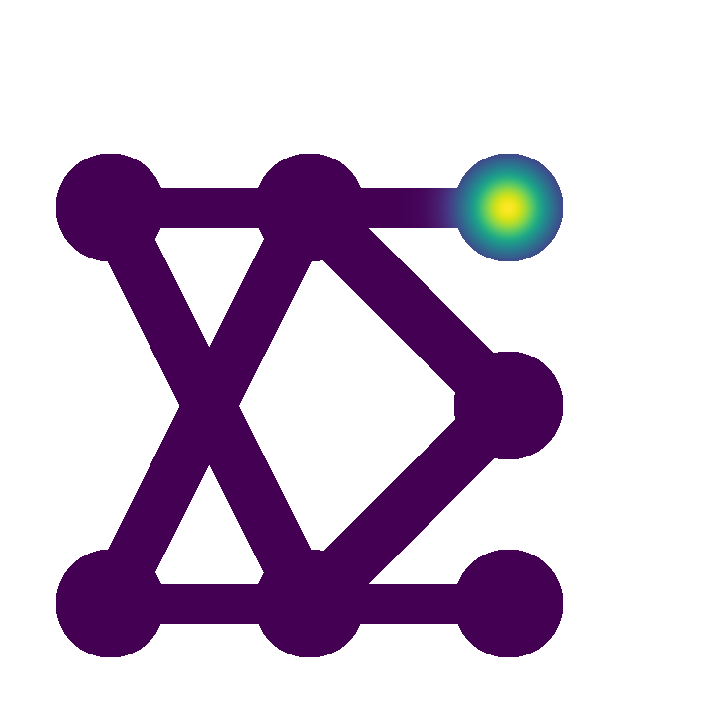

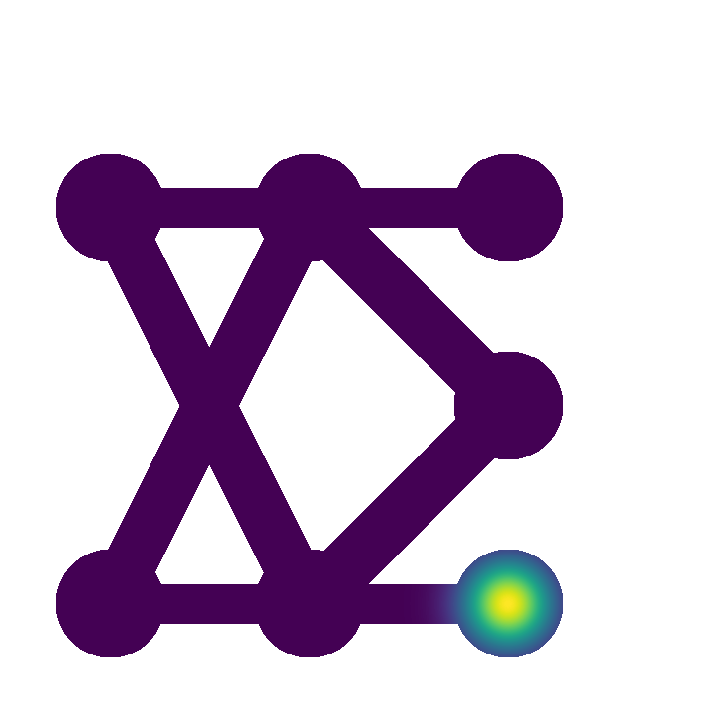

In [23]:
#pick an eigenvector


# for n in range(len(eigvecs_iti)):
for n in range(2):

    eigvec = eigvecs_iti[:,n]
    # take the real part
    eigvec = np.real(eigvec)
    # scale between -1 and 1
    eigvec = (eigvec - np.min(eigvec)) / (np.max(eigvec) - np.min(eigvec))

    # ones = np.ones(len(eigvecs_iti))

    res = 1000

    x = np.linspace(0, 5, res)
    y = np.linspace(0, 5, res)
    X, Y = np.meshgrid(x, y)
    aspect_ratio = (X[0,1] - X[0,0]) / (Y[1,0] - Y[0,0])
    Z = np.zeros((res,res))
    # for each node coordinate, get the value of the eigenvector
    for i in range(len(states_iti)):
        x_coord = node_coordinates_iti[states_iti[i]][0]
        y_coord = node_coordinates_iti[states_iti[i]][1]
        Z += eigvec[i] * np.exp(-((X - x_coord)**2 + (Y - y_coord)**2)/0.05)
    # # create a figure
    # fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))
    # #ax.set_aspect('equal')

    # ax.imshow(Z, cmap='viridis', interpolation='nearest')
    # # remove ticks



    # #ax.colorbar()
    # ax.set_title('Heatmap of Eigenvector %d on the Graph' % n)


    # Heatmap size
    H = len(Z)
    W = len(Z[0]) # Assuming all rows have the same number of columns

    data = np.random.rand(H, W)

    # Define nodes as (row, col) coordinates
    nodes = list(node_coordinates_iti.values())#[(4812, 924), (3000, 3000), (6500, 3000),(3000, 5000), (6500, 5000)]
    nodes = [(r*200, c*200) for (r, c) in nodes]
    nodes = [(c, r) for (r, c) in nodes]
    # edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5),(5,7),(6,7),(4,7)]
    edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5)]




    # node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5), 'iti': (3,0.5),'iti': (4,0.5)}


    # Create mask: True = hide, False = show
    mask = np.ones((H, W), dtype=bool)

    # Draw circular nodes
    for (r, c) in nodes:
        rr, cc = disk((r, c), radius=55, shape=mask.shape)
        mask[rr, cc] = False  # Keep circle

    # Draw edges between nodes
    for i, j in edges:
        r1, c1 = nodes[i]
        r2, c2 = nodes[j]
        rr, cc = line(r1, c1, r2, c2)
        mask[rr, cc] = False  # Keep edge
        # Optionally thicken the line
        for dr in range(-20, 20):
            for dc in range(-20, 20):
                rr2 = np.clip(rr + dr, 0, H - 1)
                cc2 = np.clip(cc + dc, 0, W - 1)
                mask[rr2, cc2] = False


    fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))

    ax = sns.heatmap(Z,mask=mask,  cmap='viridis', cbar=False)




    # remove x and y ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # invert y axis
    ax.invert_yaxis()
    # set limits xaxis
    ax.set_xlim(100, 800)

    ax.set_ylim(100, 800)


    # font arial
    plt.rc('font', family='Arial')
    # ax.set_title('Heatmap of Eigenvector / No ITI -  %d on the Graph' % n)

        # save figure as svg
    # plt.savefig(f'Figures_grids/Fig6_mouse2step_noITI_heatmap_eigenvector_{n}.pdf', format='pdf', dpi=50, bbox_inches='tight')

--------

# include ITI state 

In [24]:
states_iti = ['right','left','up','down','up_reward','down_reward','no_reward', 'iti']
node_coordinates_iti = {'right': (1,1), 'left': (1,3), 'up': (2,3), 'down': (2,1), 'up_reward': (3,3), 'down_reward': (3,1), 'no_reward': (3,2), 'iti': (4,2)}


([], [])

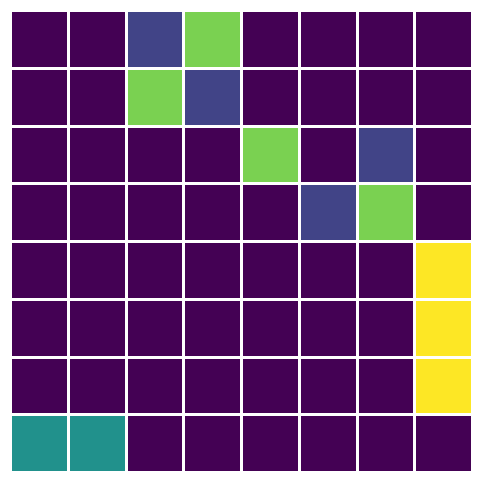

In [25]:

# define SR

graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 0.8
graph_iti[0,2] = 0.2
graph_iti[1,3] = 0.2
graph_iti[1,2] = 0.8
graph_iti[2,4] = 0.8
graph_iti[3,5] = 0.2
graph_iti[2,6] = 0.2
graph_iti[3,6] = 0.8 # down leads to no-reward mostly in this example bias block


graph_iti[4,7] = 1
graph_iti[5,7] = 1
graph_iti[6,7] = 1

graph_iti[7,1] = 0.5
graph_iti[7,0] = 0.5



# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="viridis", linecolor='white', linewidths=1, square=True, vmin=0, vmax=1, cbar=False)
# fit range of color bar
# remove ticks
plt.xticks([])
plt.yticks([])


([], [])

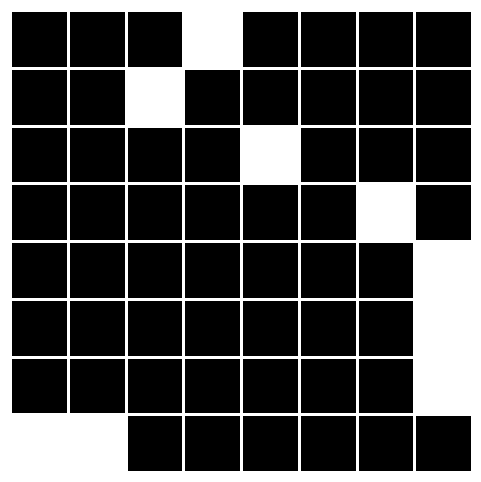

In [26]:
# define Graph
graph_iti = np.zeros((len(states_iti),len(states_iti)))
graph_iti[0,3] = 1
# graph_iti[0,2] = 0.2
# graph_iti[1,3] = 0.2
graph_iti[1,2] = 1
graph_iti[2,4] = 1
# graph_iti[3,5] = 0.2
# graph_iti[2,6] = 0.2
graph_iti[3,6] = 1 # down leads to no-reward mostly in this example bias block


graph_iti[4,7] = 1
graph_iti[5,7] = 1
graph_iti[6,7] = 1

graph_iti[7,1] = 1
graph_iti[7,0] = 1



# plot matrix
plt.figure(figsize=(6,6))
# sns.heatmap(graph_iti, annot=False, cmap='Blues', xticklabels=states_iti, yticklabels=states_iti)
sns.heatmap(graph_iti, annot=False, cmap="grey", linecolor='white', linewidths=1, cbar=False, square=True)
# remove ticks
plt.xticks([])
plt.yticks([])



In [27]:
eigvals_iti, eigvecs_iti = np.linalg.eig(graph_iti)

# extract real part of the eigenvectors
eigvecs_iti = np.real(eigvecs_iti)


In [28]:
eigvecs_iti

array([[ 0.00000000e+00, -2.70598050e-01,  1.73965581e-16,
         1.73965581e-16,  2.70598050e-01, -7.07106781e-01,
         7.07106781e-01,  7.07106781e-01],
       [ 0.00000000e+00, -2.70598050e-01,  1.19923025e-16,
         1.19923025e-16,  2.70598050e-01,  7.07106781e-01,
        -7.07106781e-01, -7.07106781e-01],
       [ 0.00000000e+00,  3.21797126e-01, -3.21797126e-01,
        -3.21797126e-01,  3.21797126e-01,  7.73821843e-17,
         1.39876435e-16,  1.39876435e-16],
       [ 0.00000000e+00,  3.21797126e-01, -3.21797126e-01,
        -3.21797126e-01,  3.21797126e-01, -7.73821843e-17,
        -1.39876435e-16, -1.39876435e-16],
       [ 0.00000000e+00, -3.82683432e-01, -2.76600579e-16,
        -2.76600579e-16,  3.82683432e-01,  4.18009159e-32,
         1.95283648e-18,  1.95283648e-18],
       [ 1.00000000e+00, -3.82683432e-01, -3.34090752e-17,
        -3.34090752e-17,  3.82683432e-01, -6.16620105e-17,
         1.22649042e-30,  1.22649042e-30],
       [ 0.00000000e+00, -3.826834

In [29]:
# estimate absoulte values



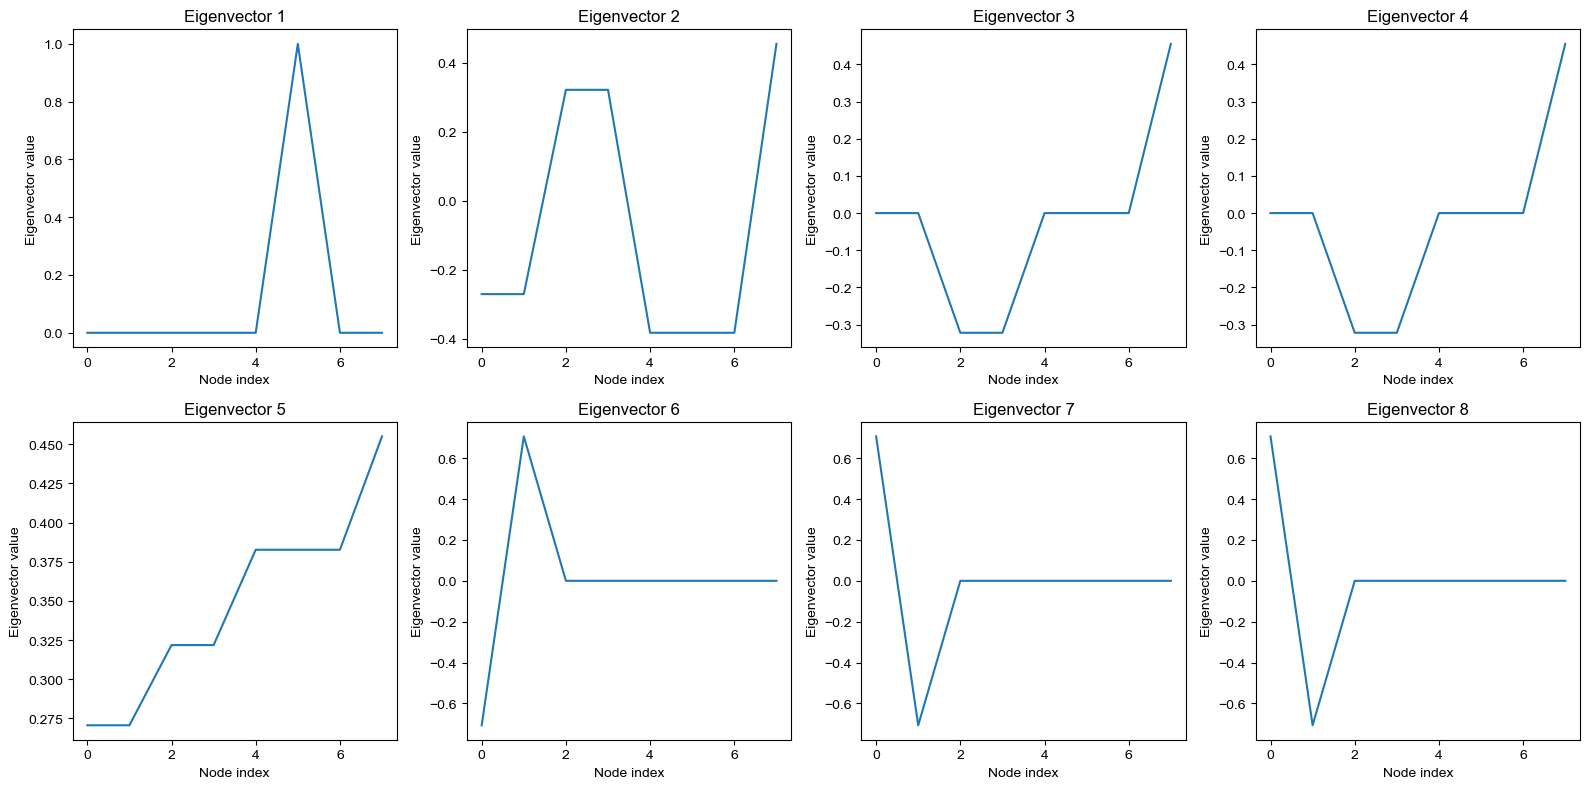

In [30]:
# plot the eigenvectors on 7 separate plots
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()
for i in range(len(eigvecs_iti)):
    ax = axs[i]
    ax.plot(eigvecs_iti[:,i])
    ax.set_title(f'Eigenvector {i+1}')
    ax.set_xlabel('Node index')
    ax.set_ylabel('Eigenvector value')
plt.tight_layout()
plt.show()

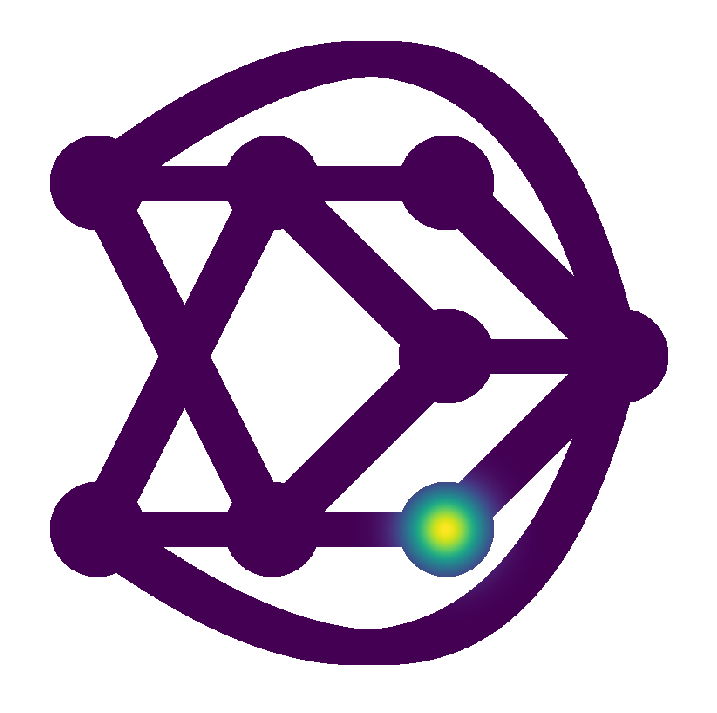

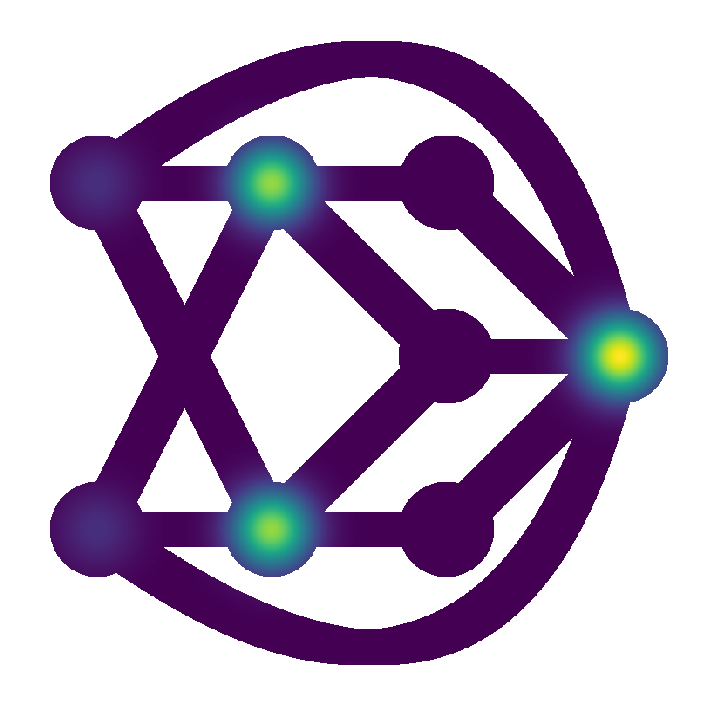

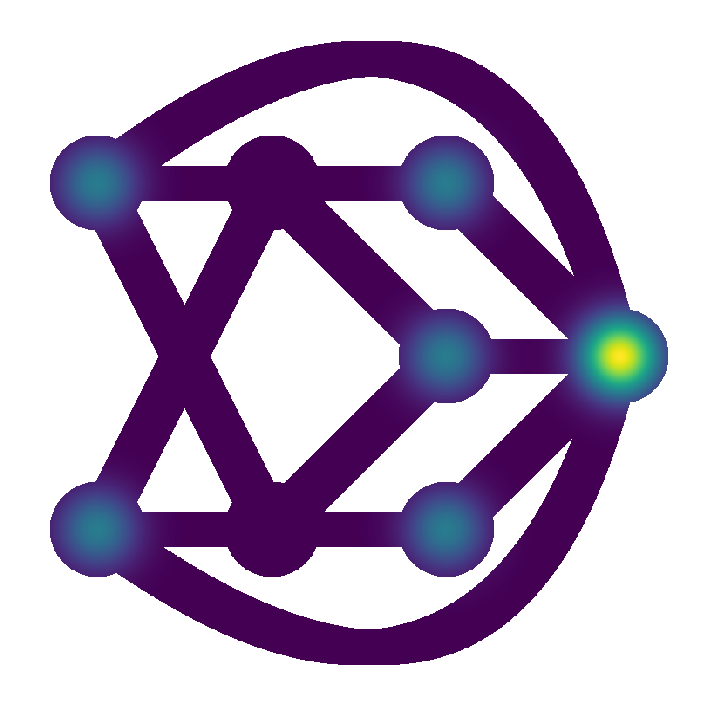

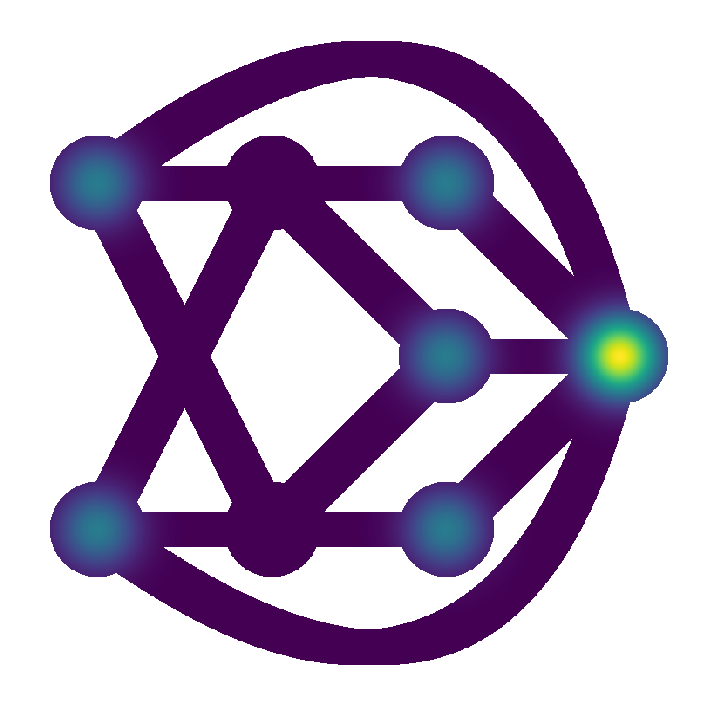

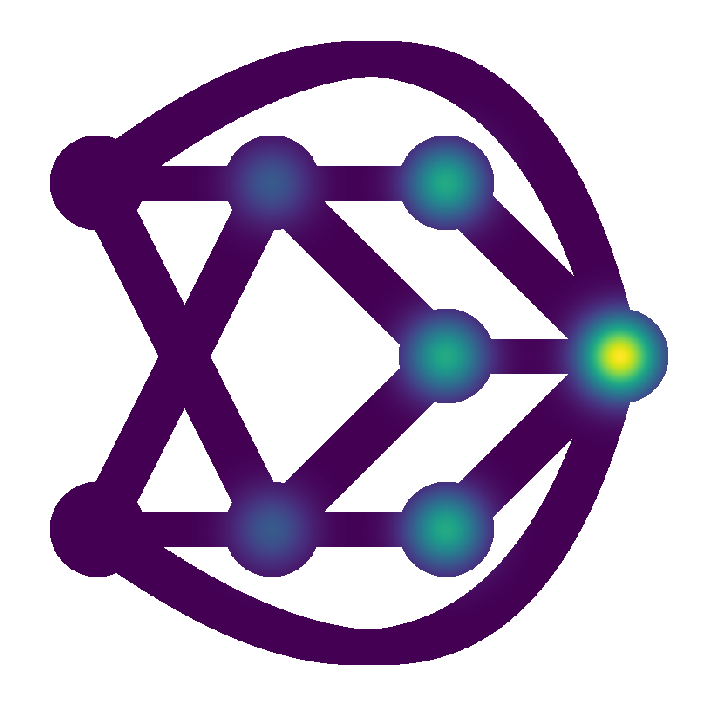

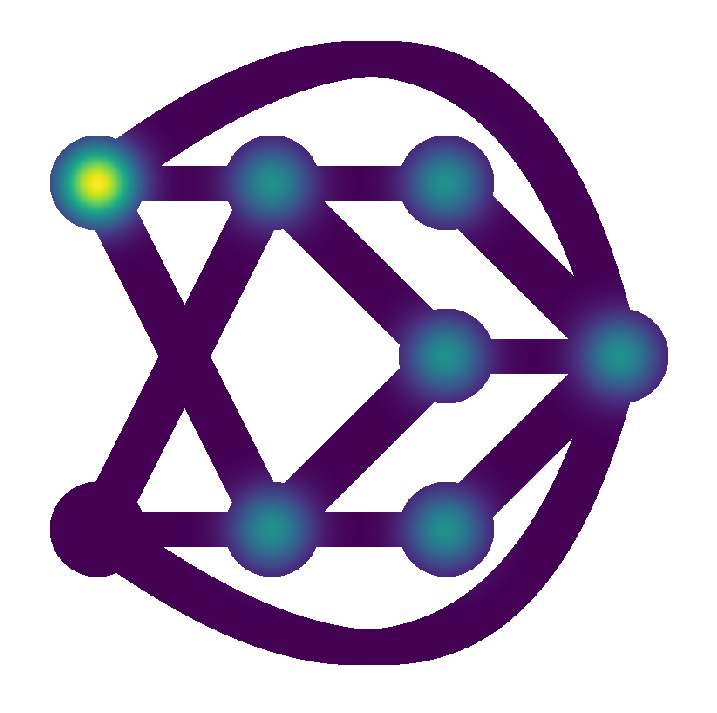

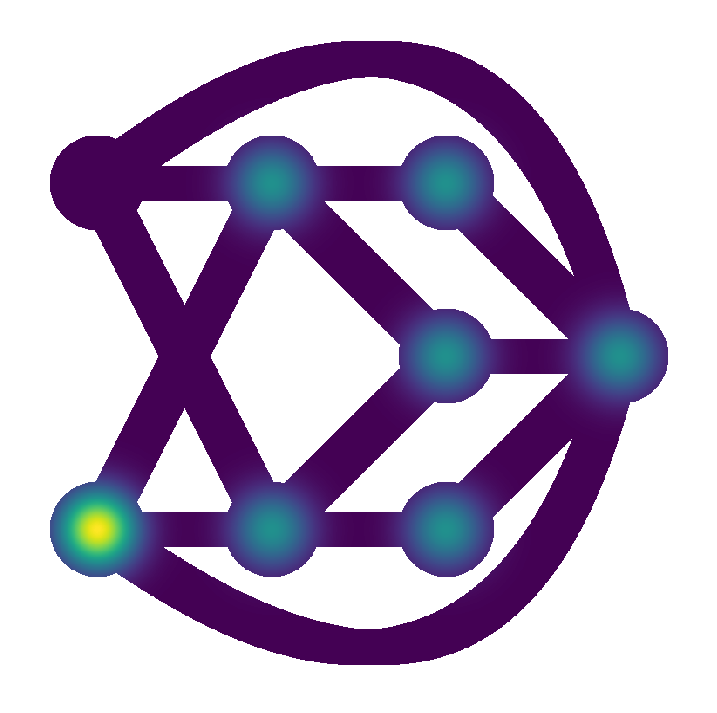

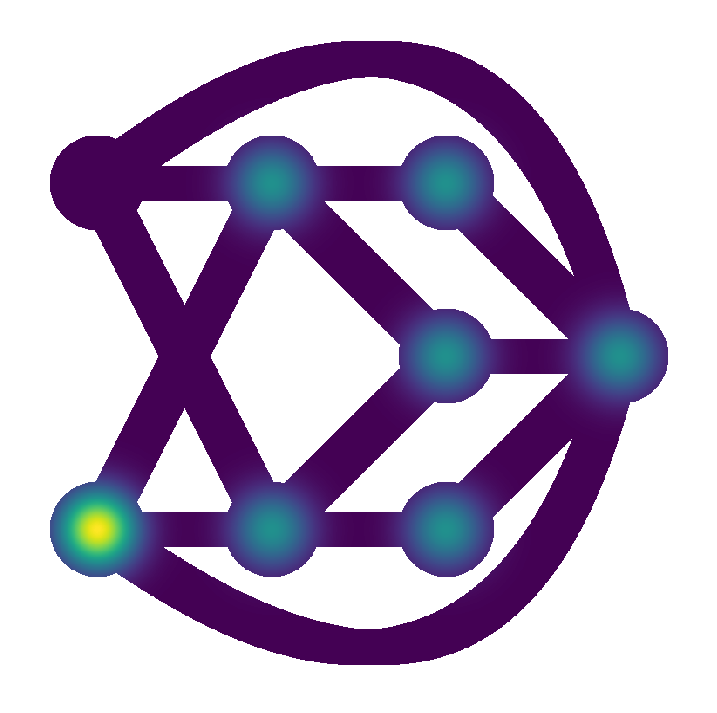

In [31]:
#pick an eigenvector
from skimage.draw import bezier_curve


for n in range(len(eigvecs_iti)):
        # n = 7
        eigvec = eigvecs_iti[:,n]
        # take the real part
        eigvec = np.real(eigvec)
        # scale between -1 and 1
        eigvec = (eigvec - np.min(eigvec)) / (np.max(eigvec) - np.min(eigvec))

        ones = np.ones(len(eigvecs_iti))

        res = 1000


        # states_iti = ['right','left','up','down','up_reward','down_reward','no_reward', 'iti']
        # node_coordinates_iti = {'right': (1,1), 'left': (1,3), 'up': (2,3), 'down': (2,1), 'up_reward': (3,3), 'down_reward': (3,1), 'no_reward': (3,2), 'iti': (4,2)}


        x = np.linspace(0, 5, res)
        y = np.linspace(0, 5, res)
        X, Y = np.meshgrid(x, y)
        aspect_ratio = (X[0,1] - X[0,0]) / (Y[1,0] - Y[0,0])
        Z = np.zeros((res,res))
        # for each node coordinate, get the value of the eigenvector
        for i in range(len(states_iti)):
            x_coord = node_coordinates_iti[states_iti[i]][0]
            y_coord = node_coordinates_iti[states_iti[i]][1]
            Z += eigvec[i] * np.exp(-((X - x_coord)**2 + (Y - y_coord)**2)/0.05)
        # create a figure
        # fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))
        # #ax.set_aspect('equal')

        # ax.imshow(Z, cmap='viridis', interpolation='nearest')
        # # remove ticks



        # #ax.colorbar()
        # ax.set_title('Heatmap of Eigenvector %d on the Graph' % n)


        # Heatmap size
        H = len(Z)
        W = len(Z[0]) # Assuming all rows have the same number of columns

        data = np.random.rand(H, W)

        # Define nodes as (row, col) coordinates
        nodes = list(node_coordinates_iti.values())#[(4812, 924), (3000, 3000), (6500, 3000),(3000, 5000), (6500, 5000)]
        nodes = [(r*200, c*200) for (r, c) in nodes]
        nodes = [(c, r) for (r, c) in nodes]
        edges = [ (1, 2), (0,2),(0,3),(1,3),(2,4),(2,6),(3,6),(3,5),(5,7),(6,7),(4,7), (7,0), (7,1)]




        # node_coordinates_iti = {'right': (0,0), 'left': (0,1), 'up': (1,1), 'down': (1,0), 'up_reward': (2,1.5), 'down_reward': (2,-0.5), 'no_reward': (2,0.5), 'iti': (3,0.5),'iti': (4,0.5)}


        # Create mask: True = hide, False = show
        mask = np.ones((H, W), dtype=bool)

        # Draw circular nodes
        for (r, c) in nodes:
            rr, cc = disk((r, c), radius=55, shape=mask.shape)
            mask[rr, cc] = False  # Keep circle


        for i, j in edges:
            r1, c1 = nodes[i]
            r2, c2 = nodes[j]

            if (i, j) == (7, 0) or (i, j) == (0, 7):
                # Curve ABOVE: control point shifted upward
                ctrl_r = (r1 + r2) * 2/3 - 550 # move up
                ctrl_c = (c1 + c2) * 2/3
                rr, cc = bezier_curve(int(r1), int(c1), int(ctrl_r), int(ctrl_c), int(r2), int(c2), 1)
            elif (i, j) == (7, 1) or (i, j) == (1, 7):
                # Curve BELOW: control point shifted downward
                ctrl_r = (r1 + r2) * 2/3 + 300  # move down
                ctrl_c = (c1 + c2) * 2/3
                rr, cc = bezier_curve(int(r1), int(c1), int(ctrl_r), int(ctrl_c), int(r2), int(c2), 1)
            else:
                rr, cc = line(int(r1), int(c1), int(r2), int(c2))

            # Apply to mask
            mask[rr, cc] = False
            for dr in range(-20, 20):
                for dc in range(-20, 20):
                    rr2 = np.clip(rr + dr, 0, H - 1)
                    cc2 = np.clip(cc + dc, 0, W - 1)
                    mask[rr2, cc2] = False


        fig, ax = plt.subplots(1, figsize=(9*aspect_ratio,9))

        ax = sns.heatmap(Z,mask=mask,  cmap='viridis', cbar=False)




        # remove x and y ticks
        ax.set_xticks([])
        ax.set_yticks([])
        # set limits xaxis
        ax.set_xlim(100, 900)

        ax.set_ylim(0, 800)

     

        # font arial
        plt.rc('font', family='Arial')
        # ax.set_title('Heatmap of Eigenvector with ITI %d on the Graph' % n)
        # plt.savefig(f'Figures_grids/Fig6_mouse2step_yesITI_heatmap_eigenvector_{n}.pdf', format='pdf', dpi=50, bbox_inches='tight')



--------

# Build analytical 12 × 12 spatial grid world in which agents moved uniformly in to four directions with reflective boundaries to construct G. Estimate eigenvectors from G.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def build_transition_matrix(N=12):
    """
    Build transition matrix P for an NxN grid with FIXED boundaries.
    Agent moves up/down/left/right uniformly among valid moves.
    
    Returns
    -------
    P : ndarray (N^2, N^2)
        Row-stochastic transition matrix.
    """
    n_states = N * N
    P = np.zeros((n_states, n_states))
    
    def idx(x, y):
        return x * N + y
    
    moves = [(1,0), (-1,0), (0,1), (0,-1)]  # down, up, right, left
    
    for x in range(N):
        for y in range(N):
            s = idx(x, y)
            valid_next = []
            for dx, dy in moves:
                u, v = x + dx, y + dy
                if 0 <= u < N and 0 <= v < N:   # only valid moves
                    valid_next.append(idx(u, v))
            prob = 1.0 / len(valid_next)        # normalize over valid moves
            for s_next in valid_next:
                P[s, s_next] = prob
    return P

def successor_representation_matrix(N=12, gamma=0.9):
    """
    Compute SR matrix as (I - gamma*P)^(-1).
    
    Returns
    -------
    M : ndarray (N^2, N^2)
        Successor representation matrix.
    """
    P = build_transition_matrix(N)
    I = np.eye(N*N)
    M = np.linalg.inv(I - gamma * P)
    return M

# Example: 12x12 grid
N = 12
gamma = 0.95
M = successor_representation_matrix(N, gamma)

print("SR matrix shape:", M.shape)   # (144, 144)
print("SR from state 0 to state 15:", M[0,15])


SR matrix shape: (144, 144)
SR from state 0 to state 15: 0.520463476470669


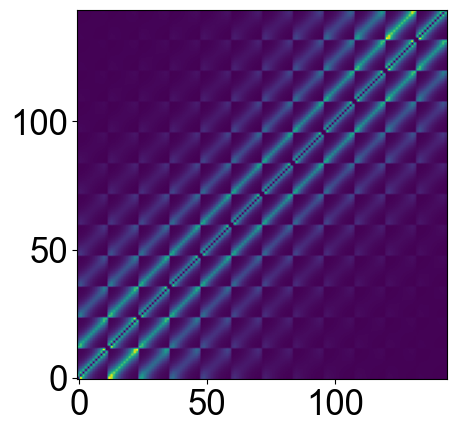

In [14]:
# Remove diagonal from M
M_no_diag = M.copy()
np.fill_diagonal(M_no_diag, 0) 
plt.imshow(M_no_diag, cmap='viridis', origin='lower')
# normalize M between 0 and 1
W = (M_no_diag - np.min(M_no_diag)) / (np.max(M_no_diag) - np.min(M_no_diag))

# binarize sucessor using threhshold X
threshold = 0.2
G = (W > threshold).astype(int)

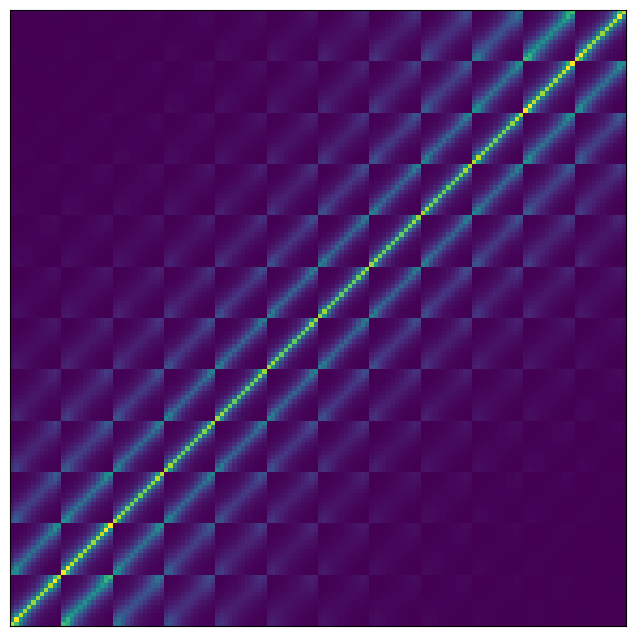

In [15]:
# save successor variable
# np.save('successor_12by12grid_thresh_randomStart_90000steps.npy', successor)


# fontsize 30 and type Arial
plt.rcParams['font.size'] = 25
plt.rcParams['font.family'] = 'Arial'



# plot successor
plt.figure(figsize=(8, 8))
plt.imshow(M, cmap='viridis', origin='lower')
# plt.colorbar(label='Successor Representation Value')
# plt.title('Successor Representation on Gridworld')
# plt.xlabel('X')
# plt.ylabel('Y')

# remove the ticks both
plt.xticks([])
plt.yticks([])


# plt.savefig('2d_analyticalRandomWalk_SR_12x12grid_TransRep_ND.svg', format='svg')

plt.show()



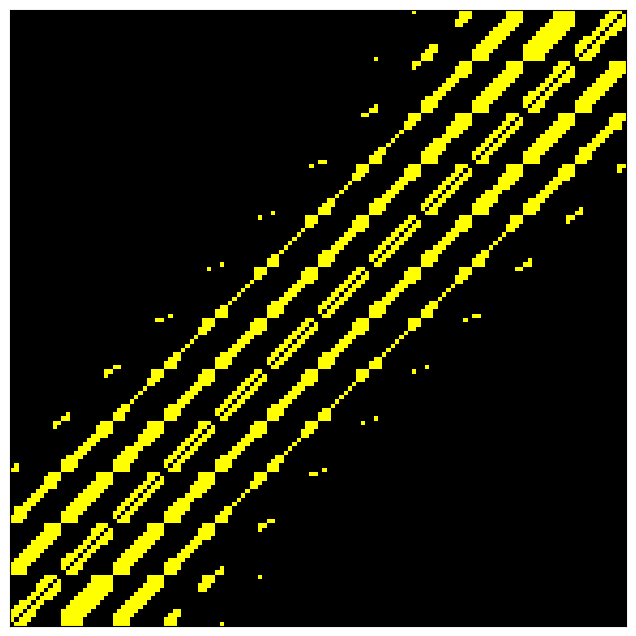

In [16]:
# save successor variable
# np.save('successor_12by12grid_thresh_randomStart_90000steps.npy', successor)
# fontsize 30 and type Arial
plt.rcParams['font.size'] = 25
plt.rcParams['font.family'] = 'Arial'



# plot successor
plt.figure(figsize=(8, 8))
plt.imshow(G, cmap='gnuplot', origin='lower')
# plt.colorbar(label='Successor Representation Value')
# plt.title('Successor Representation on Gridworld')



# remove the ticks both
plt.xticks([])
plt.yticks([])

# plt.savefig('2d_analyticalRandomWalk_graph_12x12grid_thresh_TransRep_ND.svg', format='svg')

plt.show()



In [ ]:
# Compute eigenvectors of the final learned SR
eigvals_sr, eigvecs_sr = np.linalg.eig(W)
grid_size  = 12


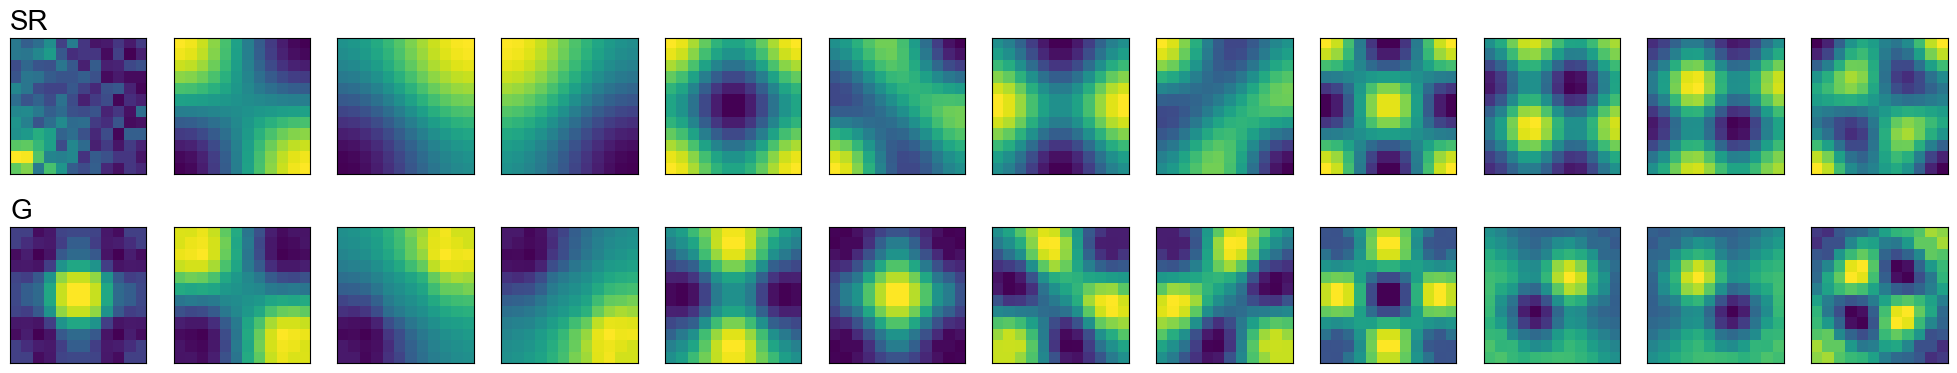

In [18]:
# generate subplots so in a single figure we see all the first 10 eigenvectors

numbe_of_grids = 12

fig, axes = plt.subplots(2,numbe_of_grids, figsize=(25, 4.5))
# axes = axes.flatten()

eigvals_sr, eigvecs_sr = np.linalg.eig(M)

# Generate eigenvectors for sucessir with thresholded SR
eigvals_G, eigvecs_G = np.linalg.eig(G)

# Choose an eigenvector to plot (e.g., the second one)

# for i in range(len(eigvecs_sr)):
for i in range(numbe_of_grids):


    eigvec_to_plot = np.real(eigvecs_sr[:, i])  # Take real part if complex

    # Reshape to grid shape
    eigvec_grid = eigvec_to_plot.reshape(grid_size, grid_size)

    axes[0, i].imshow(eigvec_grid, cmap='viridis', origin='lower')
    # plt.colorbar(label='Eigenvector Value')
    # axes[0, i].set_title(' ' + str(i) +' of SR on ')
    # plt.xlabel('X')
    # # plt.ylabel('Y')
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

    # plot the thresholded eigenvector

    eigvec_to_plot_thresh = np.real(eigvecs_G[:, i])  # Take real part if complex

    # Reshape to grid shape
    eigvec_grid_thresh = eigvec_to_plot_thresh.reshape(grid_size, grid_size)

    axes[1, i].imshow(eigvec_grid_thresh, cmap='viridis', origin='lower')
    # plt.colorbar(label='Eigenvector Value')
    # axes[1, i].set_title(' ' + str(i) +' of SR (Thresholded) on ')
    # plt.xlabel('X')
    # # plt.ylabel('Y')

    # hide ticks
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

    if i == 0:
        axes[0,i].set_title('SR', fontsize=20, loc = 'left')
        axes[1,i].set_title('G', fontsize=20, loc = 'left')




    # save svg
# plt.savefig('Figures_grids/2d_analyticalRandomWalk_eigenvector_12x12grid_Thresh_vs_Norm_Overall_ND.svg', format='svg')